# Final Project

Option: B - Algorithm Implementation

Project: Breast Cancer Tumor Classification

Anika Joshi-Awasthi, Brianna Wang, Fetra Ramiandrisoa



In [ ]:
import sys
import os
import glob
from google.colab import drive
from google.colab import files

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from scipy.stats import spearmanr

# !pip install mlxtend  # run once to install mlxtend
from mlxtend.plotting import plot_decision_regions
from xgboost import XGBClassifier

sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42

## Load datasets

Dataset 1 — Breast Cancer Wisconsin (Diagnostic)

Dataset 2 — Coimbra Breast Cancer

Dataset 3 - Mammographic Mass

In [ ]:
# Load datasets
# Upload the file on the side of colab. It will disappear everytime colab times out.

# ── Dataset 1: Wisconsin ──────────────
df1 = pd.read_csv("/content/breast-cancer.csv")
print("=== Dataset 1: Wisconsin ===")
print("Shape:", df1.shape)
print("\nClass distribution (M = malignant, B = benign):")
print(df1["diagnosis"].value_counts())
df1.head()

=== Dataset 1: Wisconsin ===
Shape: (569, 32)

Class distribution (M = malignant, B = benign):
diagnosis
B    357
M    212
Name: count, dtype: int64


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
# ── Dataset 2: Coimbra ──────────────
df2 = pd.read_csv("/content/Coimbra_breast_cancer_dataset.csv")
print('=== Dataset 2: Coimbra ===')
print('Shape:', df2.shape)
print('\nClass distribution: 1 = healthy, 2 = patient')
print(df2['Classification'].value_counts())
df2.head()

=== Dataset 2: Coimbra ===
Shape: (4000, 10)

Class distribution: 1 = healthy, 2 = patient
Classification
2    2216
1    1784
Name: count, dtype: int64


,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP.1,Classification
0,54,35.207389,103,5.642,1.378660,65.6699,9.738408,31.17499,197.660,1
1,52,22.978520,132,6.054,1.145435,47.5445,3.627241,23.03327,423.361,2
2,32,21.101341,87,5.668,1.008595,50.5074,5.067841,9.51156,897.034,2
3,42,26.761205,132,2.875,1.003837,16.8972,10.096475,9.75652,267.744,1
4,55,34.232520,76,3.120,1.597721,17.6852,11.845054,17.21541,788.552,2


In [ ]:
# ── Dataset 3: Mammographic Mass ──────────────

!pip install ucimlrepo -q   # run to install ucimlrepo
from ucimlrepo import fetch_ucirepo

mammo = fetch_ucirepo(id=161)
df3 = mammo.data.features.copy()
df3["target"] = mammo.data.targets.values.ravel()  # 0=benign, 1=malignant

# Drop BI-RADS: it is a radiologist summary assessment that encodes the diagnosis itself, including it would constitute data leakage
df3 = df3.drop(columns=["BI-RADS"], errors="ignore")
df3 = df3.dropna().reset_index(drop=True)

print("=== Dataset 3: Mammographic Mass ===")
print("Shape:", df3.shape)
print("\nClass distribution (1 = malignant, 0 = benign):")
print(df3["target"].value_counts())
print("\nFeatures:", df3.columns.tolist())
df3.head()

=== Dataset 3: Mammographic Mass ===
Shape: (831, 5)

Class distribution (1 = malignant, 0 = benign):
target
0    428
1    403
Name: count, dtype: int64

Features: ['Age', 'Shape', 'Margin', 'Density', 'target']


,Age,Shape,Margin,Density,target
0,67.0,3.0,5.0,3.0,1
1,58.0,4.0,5.0,3.0,1
2,28.0,1.0,1.0,3.0,0
3,57.0,1.0,5.0,3.0,1
4,76.0,1.0,4.0,3.0,1


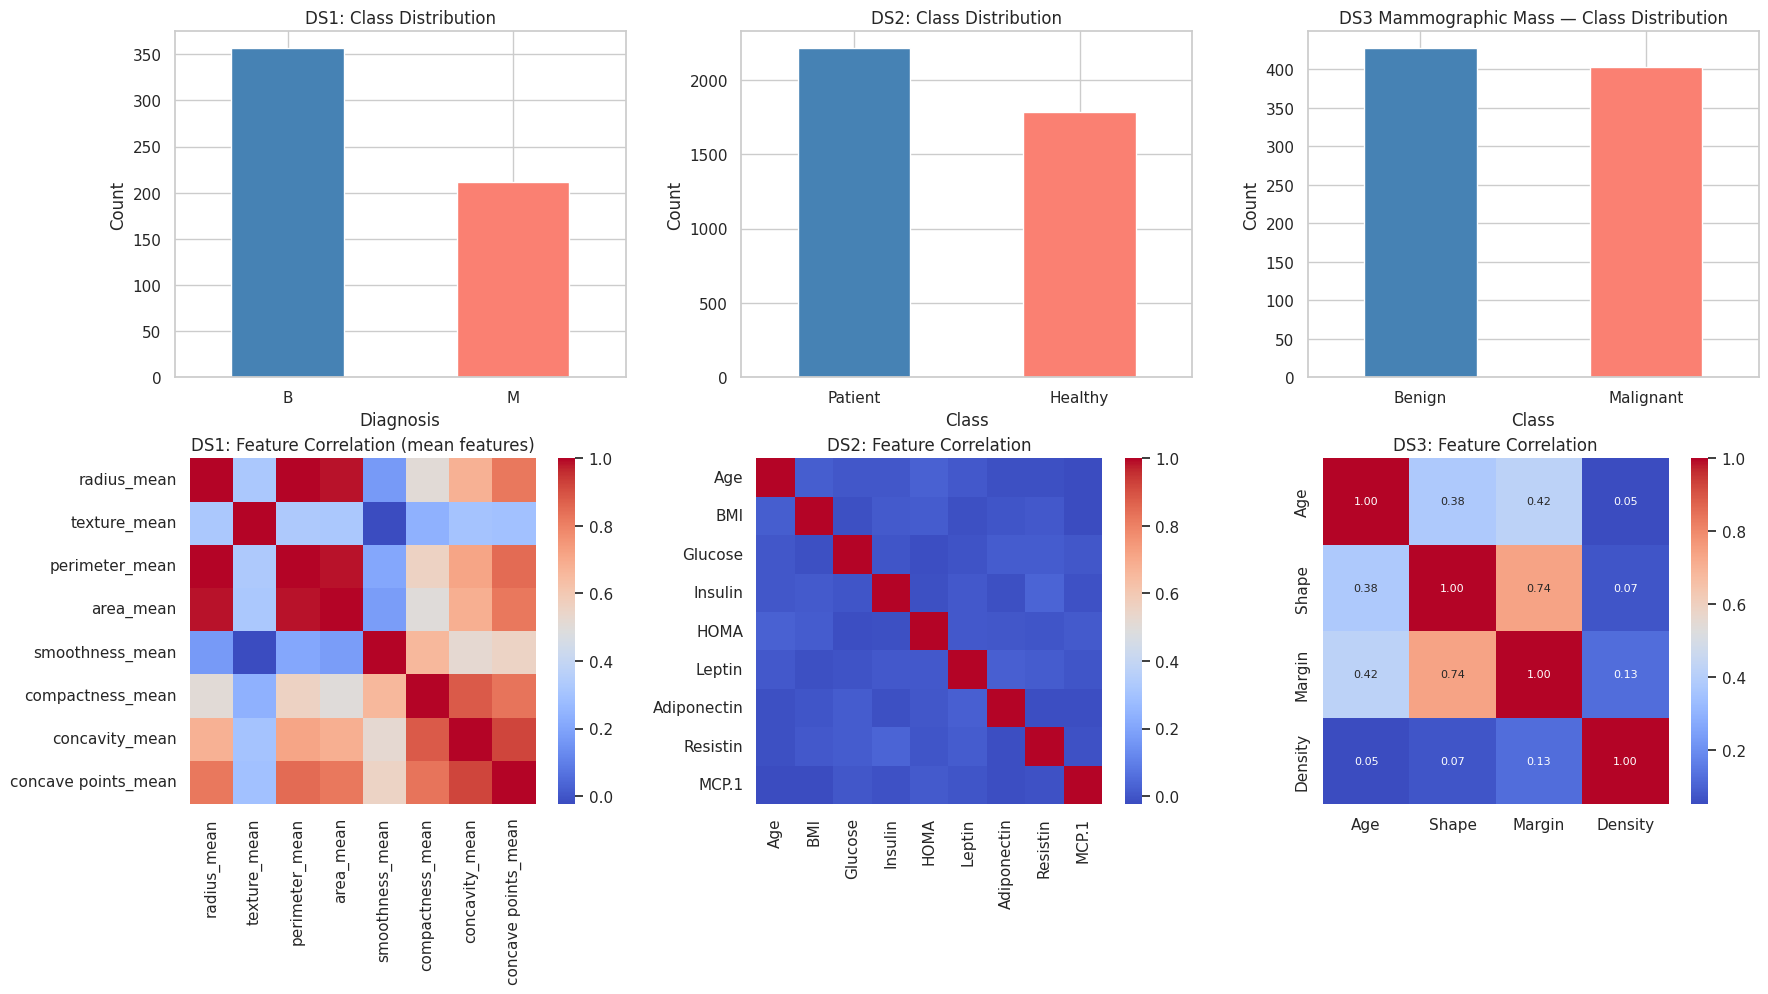

In [ ]:
# Dataset distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Wisconsin (DS1) class distribution
df1["diagnosis"].value_counts().plot(kind="bar", ax=axes[0, 0], color=["steelblue", "salmon"])
axes[0, 0].set_title("DS1: Class Distribution")
axes[0, 0].set_xlabel("Diagnosis"); axes[0, 0].set_ylabel("Count")
axes[0, 0].tick_params(axis="x", rotation=0)

# Coimbra (DS2) class distribution
df2['Classification'].map({1: 'Healthy', 2: 'Patient'}).value_counts().plot(kind='bar', ax=axes[0, 1], color=['steelblue', 'salmon'])
axes[0, 1].set_title('DS2: Class Distribution')
axes[0, 1].set_xlabel('Class'); axes[0, 1].set_ylabel('Count')
axes[0, 1].tick_params(axis='x', rotation=0)

# Mammographic mass (DS3) class distribution
df3["target"].map({0: "Benign", 1: "Malignant"}).value_counts().plot(kind="bar", ax=axes[0, 2], color=["steelblue", "salmon"])
axes[0, 2].set_title("DS3 Mammographic Mass — Class Distribution")
axes[0, 2].set_xlabel("Class"); axes[0, 2].set_ylabel("Count")
axes[0, 2].tick_params(axis="x", rotation=0)

# DS1 correlation heatmap (mean features)
mean_features = ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
                 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean']
sns.heatmap(df1[mean_features].corr(), ax=axes[1, 0], annot=False,
            cmap='coolwarm', square=True)
axes[1, 0].set_title('DS1: Feature Correlation (mean features)')

# DS2 correlation heatmap
sns.heatmap(df2.drop('Classification', axis=1).corr(), ax=axes[1, 1],
            annot=False, cmap='coolwarm', square=True)
axes[1, 1].set_title('DS2: Feature Correlation')

# DS3 correlation heatmap
sns.heatmap(df3.drop("target", axis=1).corr(), ax=axes[1, 2], annot=True, fmt=".2f",
            cmap="coolwarm", square=True, annot_kws={"size": 8})
axes[1, 2].set_title("DS3: Feature Correlation")

plt.tight_layout()
plt.show()

## Feature Selection
Two complementary methods are used to identify informative features:
- ANOVA F-test (`SelectKBest`) - fast univariate statistical ranking
- Random Forest importances - captures non-linear interactions between features

Dataset 1 has 30 features; we keep the top 10 for distance-based models (LR, KNN, SVM, MLP). Dataset 2 and 3 have few features so all are retained.

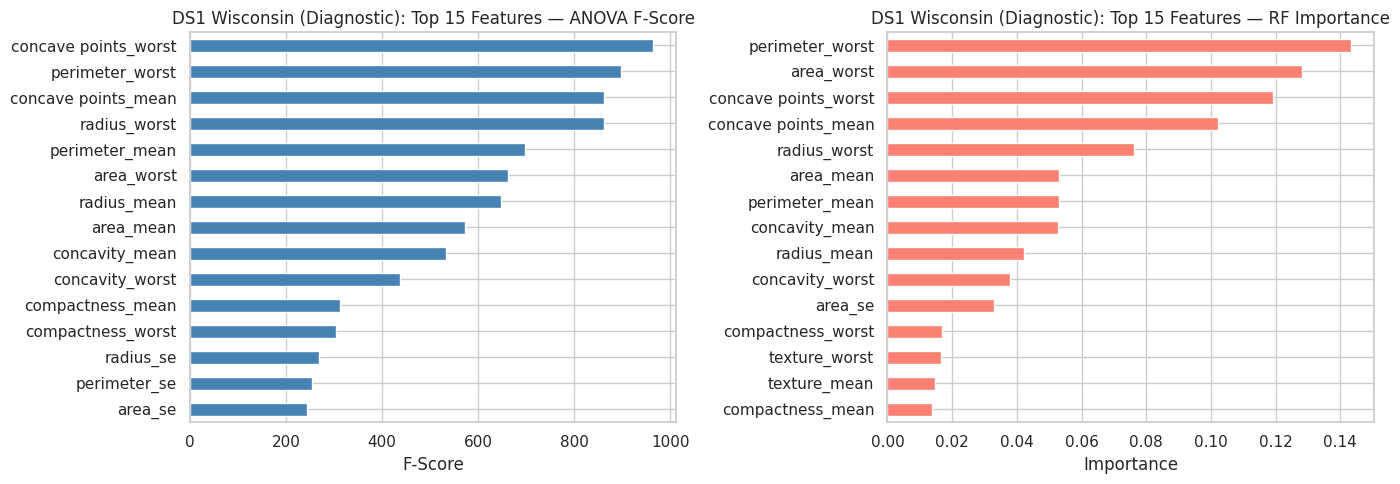

Top 10 features selected for DS1: ['concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst', 'perimeter_mean', 'area_worst', 'radius_mean', 'area_mean', 'concavity_mean', 'concavity_worst']


In [ ]:
# Feature selection

# ── Dataset 1 ──────────────────────────────────
X1_all = df1.drop(["id", "diagnosis"], axis=1)
y1 = (df1["diagnosis"] == "M").astype(int)

# ANOVA F-test (SelectKBest)
selector1 = SelectKBest(f_classif, k="all").fit(X1_all, y1)
f_scores1 = pd.Series(selector1.scores_, index=X1_all.columns).sort_values(ascending=False)

# Random Forest importances
rf_probe1 = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE).fit(X1_all, y1)
rf_imp1 = pd.Series(rf_probe1.feature_importances_, index=X1_all.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
f_scores1.head(15).plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].invert_yaxis(); axes[0].set_title("DS1 Wisconsin (Diagnostic): Top 15 Features — ANOVA F-Score"); axes[0].set_xlabel("F-Score")
rf_imp1.head(15).plot(kind="barh", ax=axes[1], color="salmon")
axes[1].invert_yaxis(); axes[1].set_title("DS1 Wisconsin (Diagnostic): Top 15 Features — RF Importance"); axes[1].set_xlabel("Importance")
plt.tight_layout()
plt.show()

TOP_K = 10
top_features1 = f_scores1.head(TOP_K).index.tolist()
print(f"Top {TOP_K} features selected for DS1:", top_features1)

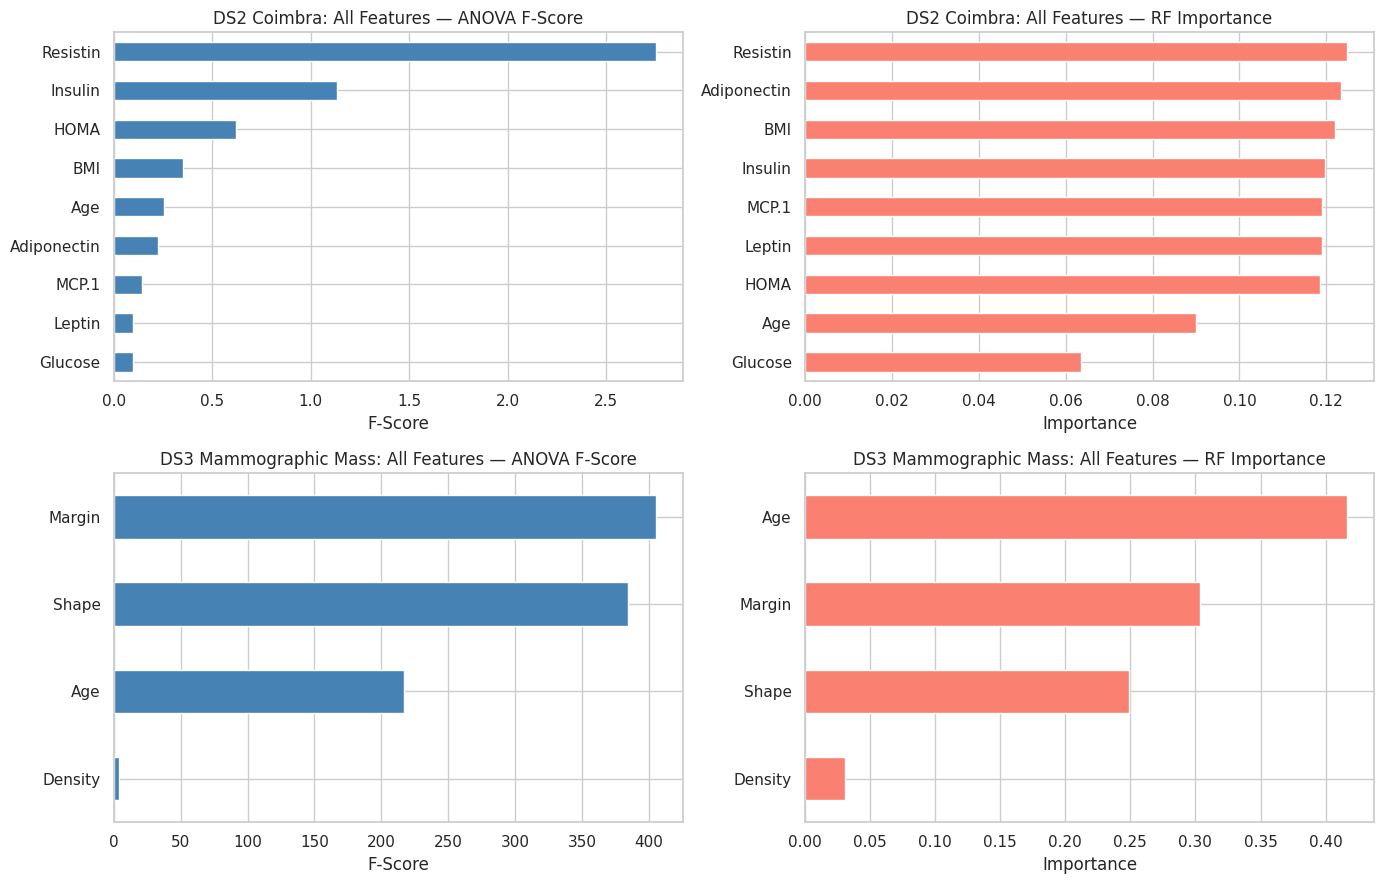

Features used for DS2: ['Age', 'BMI', 'Glucose', 'Insulin', 'HOMA', 'Leptin', 'Adiponectin', 'Resistin', 'MCP.1']
Features used for DS3: ['Age', 'Shape', 'Margin', 'Density']


In [ ]:
# ── Dataset 2 and 3 ──────────────────────────────────
X2_all = df2.drop("Classification", axis=1)
y2 = (df2["Classification"] == 2).astype(int)   # 1 = patient

X3_all = df3.drop("target", axis=1)
y3 = df3["target"]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for row, (X, y, label) in enumerate([(X2_all, y2, "DS2 Coimbra"), (X3_all, y3, "DS3 Mammographic Mass")]):
  sel = SelectKBest(f_classif, k="all").fit(X, y)
  fs = pd.Series(sel.scores_, index=X.columns).sort_values(ascending=False)
  rf_p = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE).fit(X, y)
  ri = pd.Series(rf_p.feature_importances_, index=X.columns).sort_values(ascending=False)

  fs.plot(kind="barh", ax=axes[row, 0], color="steelblue")
  axes[row, 0].invert_yaxis()
  axes[row, 0].set_title(f"{label}: All Features — ANOVA F-Score")
  axes[row, 0].set_xlabel("F-Score")

  ri.plot(kind="barh", ax=axes[row, 1], color="salmon")
  axes[row, 1].invert_yaxis()
  axes[row, 1].set_title(f"{label}: All Features — RF Importance")
  axes[row, 1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

top_features2 = X2_all.columns.tolist()
top_features3 = X3_all.columns.tolist()
print("Features used for DS2:", top_features2)
print("Features used for DS3:", top_features3)

## Splitting data
- 80/20 stratified split on both datasets (preserves class ratio in each split)
- `StandardScaler` fit only on training data, then applied to test to prevent data leakage
- Dataset 1: two versions - top 10 features for LR/KNN/SVM/MLP, all features for Random Forest
- Datasets 2 and 3: all features used (too few to warrant further selection)
- Shared `StratifiedKFold` (k=5) cross-validator used in all `GridSearchCV` calls

In [ ]:
# Splitting data

# ── Dataset 1 ─────────────────────────────────
X1_top = X1_all[top_features1]
X1_tr, X1_te, y1_tr, y1_te = train_test_split(X1_top, y1, test_size=0.2, random_state=RANDOM_STATE, stratify=y1)
X1_tr_all, X1_te_all, _, _ = train_test_split(X1_all, y1, test_size=0.2, random_state=RANDOM_STATE, stratify=y1)

sc1 = StandardScaler()
X1_tr_s = sc1.fit_transform(X1_tr)
X1_te_s = sc1.transform(X1_te)

# ── Dataset 2 ──────────────────────────────────
X2_tr, X2_te, y2_tr, y2_te = train_test_split(X2_all, y2, test_size=0.2, random_state=RANDOM_STATE, stratify=y2)

sc2 = StandardScaler()
X2_tr_s = sc2.fit_transform(X2_tr)
X2_te_s = sc2.transform(X2_te)

# ── Dataset 3 ──────────────────────────────────
X3_tr, X3_te, y3_tr, y3_te = train_test_split(X3_all, y3, test_size=0.2, random_state=RANDOM_STATE, stratify=y3)

sc3 = StandardScaler()
X3_tr_s = sc3.fit_transform(X3_tr)
X3_te_s = sc3.transform(X3_te)

# Shared cross-validation splitter
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("DS1 — Train:", X1_tr.shape[0], " | Test:", X1_te.shape[0])
print("DS2 — Train:", X2_tr.shape[0], " | Test:", X2_te.shape[0])
print("DS3 — Train:", X3_tr.shape[0], " | Test:", X3_te.shape[0])

DS1 — Train: 455  | Test: 114
DS2 — Train: 3200  | Test: 800
DS3 — Train: 664  | Test: 167


### Evaluation function

In [ ]:
def evaluate_model(name, y_true, y_pred, y_prob=None, ax_cm=None):
  """Compute and print all metrics; optionally plot confusion matrix."""
  acc = accuracy_score(y_true, y_pred)
  prec = precision_score(y_true, y_pred, zero_division=0)
  rec = recall_score(y_true, y_pred, zero_division=0)
  f1 = f1_score(y_true, y_pred, zero_division=0)
  auc = roc_auc_score(y_true, y_prob) if y_prob is not None else float("nan")

  print(f"\n=== {name} ===")
  print(f"  Accuracy : {acc:.4f}")
  print(f"  Precision: {prec:.4f}")
  print(f"  Recall   : {rec:.4f}")
  print(f"  F1 Score : {f1:.4f}")
  if y_prob is not None:
    print(f"  ROC-AUC  : {auc:.4f}")

  if ax_cm is not None:
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["Benign/Healthy", "Malignant/Patient"]).plot(ax=ax_cm, cmap="Blues", colorbar=False)
    ax_cm.set_title(name)

  return dict(name=name, accuracy=acc, precision=prec, recall=rec, f1=f1, auc=auc)

### Custom recall scorer
`scoring='recall'` in `GridSearchCV` measures recall of class 1 by default, but if GridSearch
can achieve recall = 1.0 by predicting the majority class for everything, it will.
We fix this by using a custom scorer that explicitly pins `pos_label=1` (malignant/patient)
AND by adding a minimum precision floor via F1 as a tiebreaker. All GridSearchCV calls below
use `recall_malignant` as the primary scorer.

In [ ]:
from sklearn.metrics import make_scorer

# Primary scorer: recall of class 1 (malignant/patient) only
recall_malignant = make_scorer(recall_score, pos_label=1, zero_division=0)

# We use recall_malignant everywhere in GridSearchCV so the optimizer
# can never game the metric by predicting the wrong majority class.

## Logistic Regression
Linear baseline model.

Uses the top 10 ANOVA-selected features for DS1 (upgraded from the original 2-feature baseline), all features for DS2 and DS3

Recall is the key metric (missed malignant diagnosis is more harmful than false positive)


=== LR — Wisconsin ===
  Accuracy : 0.9561
  Precision: 0.9744
  Recall   : 0.9048
  F1 Score : 0.9383
  ROC-AUC  : 0.9974

=== LR — Coimbra ===
  Accuracy : 0.5525
  Precision: 0.5532
  Recall   : 0.9977
  F1 Score : 0.7118
  ROC-AUC  : 0.4947

=== LR — Mammographic ===
  Accuracy : 0.7725
  Precision: 0.7654
  Recall   : 0.7654
  F1 Score : 0.7654
  ROC-AUC  : 0.8505


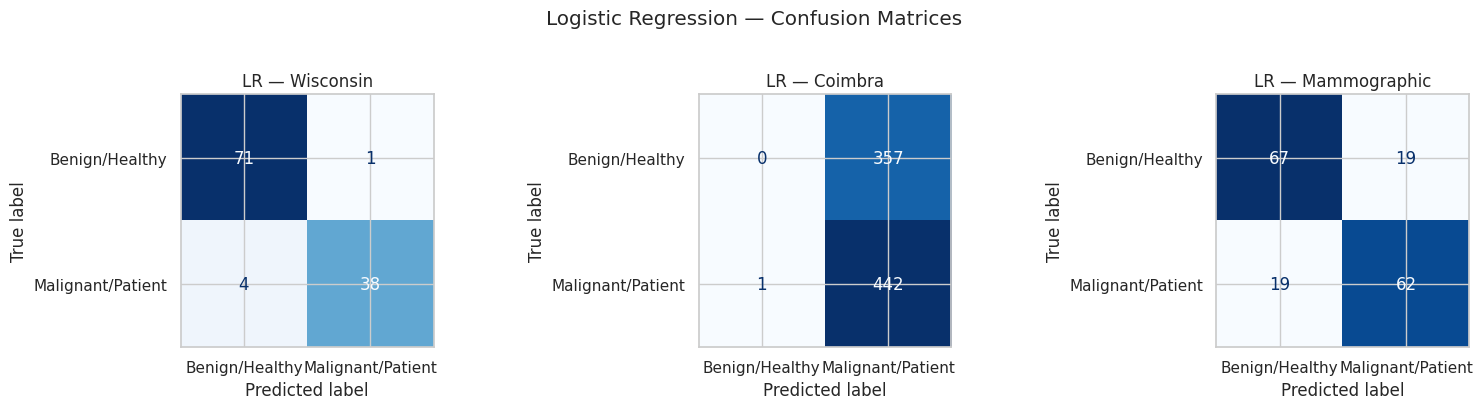

In [ ]:
# Logistic Regression
lr1 = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr1.fit(X1_tr_s, y1_tr)
y1_pred_lr = lr1.predict(X1_te_s)
y1_prob_lr = lr1.predict_proba(X1_te_s)[:, 1]

lr2 = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr2.fit(X2_tr_s, y2_tr)
y2_pred_lr = lr2.predict(X2_te_s)
y2_prob_lr = lr2.predict_proba(X2_te_s)[:, 1]

lr3 = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr3.fit(X3_tr_s, y3_tr)
y3_pred_lr = lr3.predict(X3_te_s)
y3_prob_lr = lr3.predict_proba(X3_te_s)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
res1_lr = evaluate_model("LR — Wisconsin", y1_te, y1_pred_lr, y1_prob_lr, ax_cm=axes[0])
res2_lr = evaluate_model("LR — Coimbra", y2_te, y2_pred_lr, y2_prob_lr, ax_cm=axes[1])
res3_lr = evaluate_model("LR — Mammographic", y3_te, y3_pred_lr, y3_prob_lr, ax_cm=axes[2])
plt.suptitle("Logistic Regression — Confusion Matrices", y=1.02)
plt.tight_layout()
plt.show()

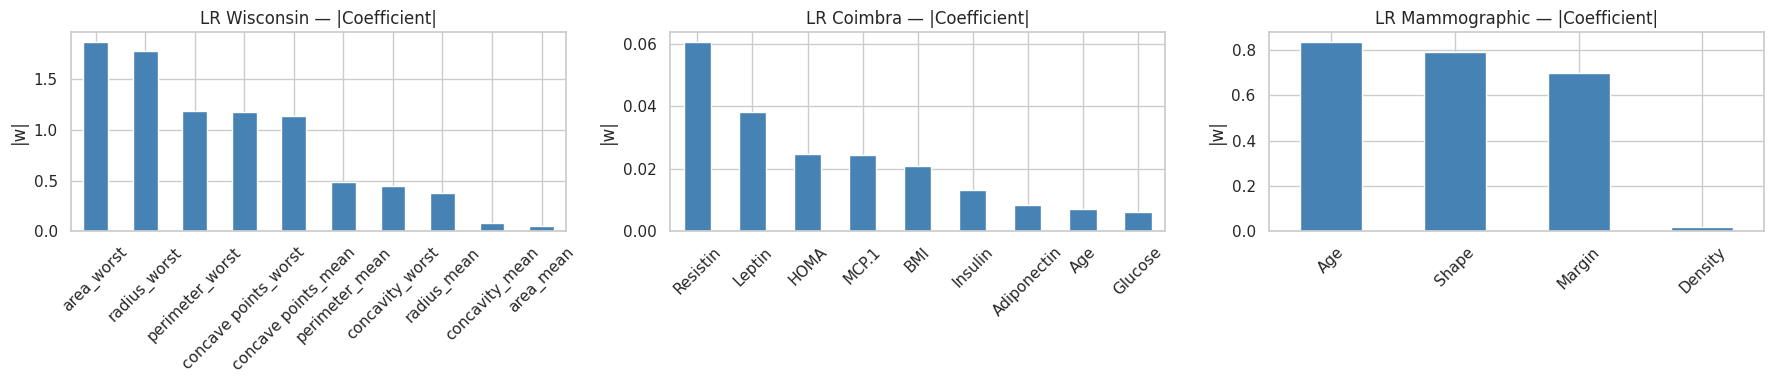

In [ ]:
# Feature coefficient plots
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

pd.Series(np.abs(lr1.coef_[0]), index=top_features1).sort_values(ascending=False).plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("LR Wisconsin — |Coefficient|"); axes[0].set_ylabel("|w|")
axes[0].tick_params(axis="x", rotation=45)

pd.Series(np.abs(lr2.coef_[0]), index=top_features2).sort_values(ascending=False).plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("LR Coimbra — |Coefficient|"); axes[1].set_ylabel("|w|")
axes[1].tick_params(axis="x", rotation=45)

pd.Series(np.abs(lr3.coef_[0]), index=top_features3).sort_values(ascending=False).plot(kind="bar", ax=axes[2], color="steelblue")
axes[2].set_title("LR Mammographic — |Coefficient|"); axes[2].set_ylabel("|w|")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Random Forest

Ensemble of decision trees that reduces variance through bagging.

`GridSearchCV` with 5-fold stratified CV explores `n_estimators`, `max_depth`, `min_samples_leaf`, and `min_samples_split`. Class weights are balanced.

Decision threshold lowered to 0.3 for Dataset 1 to prioritise recall. Datasets 2 and 3 use the default 0.5 threshold.

DS1 — Best params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
DS1 — Best CV recall: 0.9529

DS2 — Best params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
DS2 — Best CV recall: 0.7326

DS3 — Best params: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 100}
DS3 — Best CV recall: 0.8792

=== RF — Wisconsin ===
  Accuracy : 0.9649
  Precision: 0.9524
  Recall   : 0.9524
  F1 Score : 0.9524
  ROC-AUC  : 0.9967

=== RF — Coimbra ===
  Accuracy : 0.5250
  Precision: 0.5540
  Recall   : 0.7291
  F1 Score : 0.6296
  ROC-AUC  : 0.5057

=== RF — Mammographic ===
  Accuracy : 0.7784
  Precision: 0.7683
  Recall   : 0.7778
  F1 Score : 0.7730
  ROC-AUC  : 0.8516


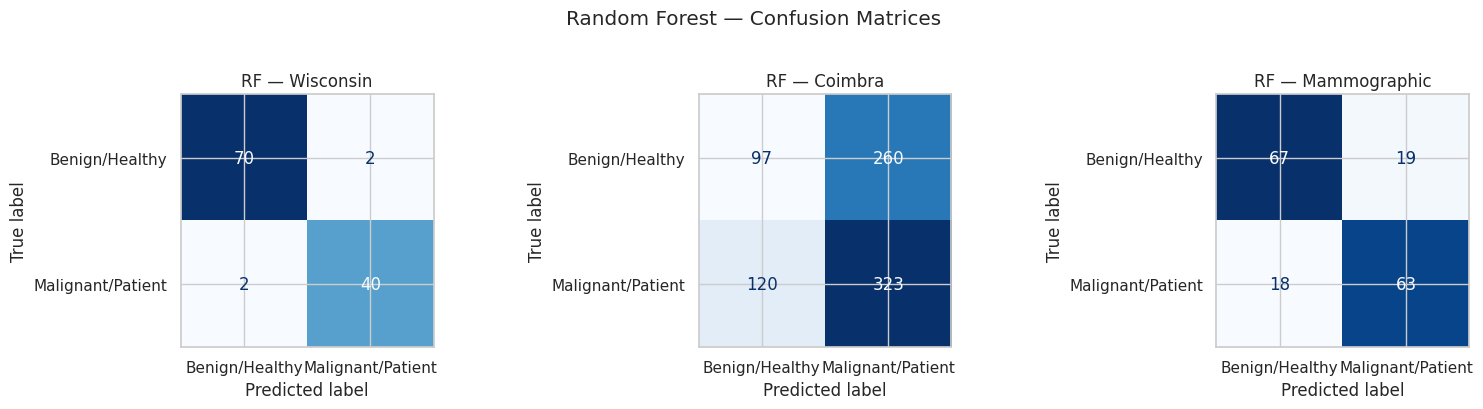

In [ ]:
# Random Forest
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 2, 4],
    "min_samples_split": [2, 5, 10]
}

# ── Dataset 1 ───────────────────────────────────
gs_rf1 = GridSearchCV(RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE),
                      param_grid_rf, scoring=recall_malignant, cv=cv, n_jobs=-1, verbose=0)
gs_rf1.fit(X1_tr_all, y1_tr)
print("DS1 — Best params:", gs_rf1.best_params_)
print("DS1 — Best CV recall:", round(gs_rf1.best_score_, 4))

y1_prob_rf_raw = gs_rf1.best_estimator_.predict_proba(X1_te_all)[:, 1]
y1_prob_rf = y1_prob_rf_raw
y1_pred_rf = (y1_prob_rf > 0.3).astype(int)   # threshold lowered for recall

# ── Dataset 2 ────────────────────────────────────
gs_rf2 = GridSearchCV(RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE),
                      param_grid_rf, scoring=recall_malignant, cv=cv, n_jobs=-1, verbose=0)
gs_rf2.fit(X2_tr_s, y2_tr)
print("\nDS2 — Best params:", gs_rf2.best_params_)
print("DS2 — Best CV recall:", round(gs_rf2.best_score_, 4))

y2_prob_rf = gs_rf2.best_estimator_.predict_proba(X2_te_s)[:, 1]
y2_pred_rf = (y2_prob_rf > 0.5).astype(int)

# ── Dataset 3 ──────────────────────────────────────
gs_rf3 = GridSearchCV(RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE),
                      param_grid_rf, scoring=recall_malignant, cv=cv, n_jobs=-1, verbose=0)
gs_rf3.fit(X3_tr_s, y3_tr)
print("\nDS3 — Best params:", gs_rf3.best_params_)
print("DS3 — Best CV recall:", round(gs_rf3.best_score_, 4))

y3_prob_rf = gs_rf3.best_estimator_.predict_proba(X3_te_s)[:, 1]
y3_pred_rf = (y3_prob_rf > 0.5).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
res1_rf = evaluate_model("RF — Wisconsin", y1_te, y1_pred_rf, y1_prob_rf, ax_cm=axes[0])
res2_rf = evaluate_model("RF — Coimbra",   y2_te, y2_pred_rf, y2_prob_rf, ax_cm=axes[1])
res3_rf = evaluate_model("RF — Mammographic",   y3_te, y3_pred_rf, y3_prob_rf, ax_cm=axes[2])
plt.suptitle("Random Forest — Confusion Matrices", y=1.02)
plt.tight_layout()
plt.show()

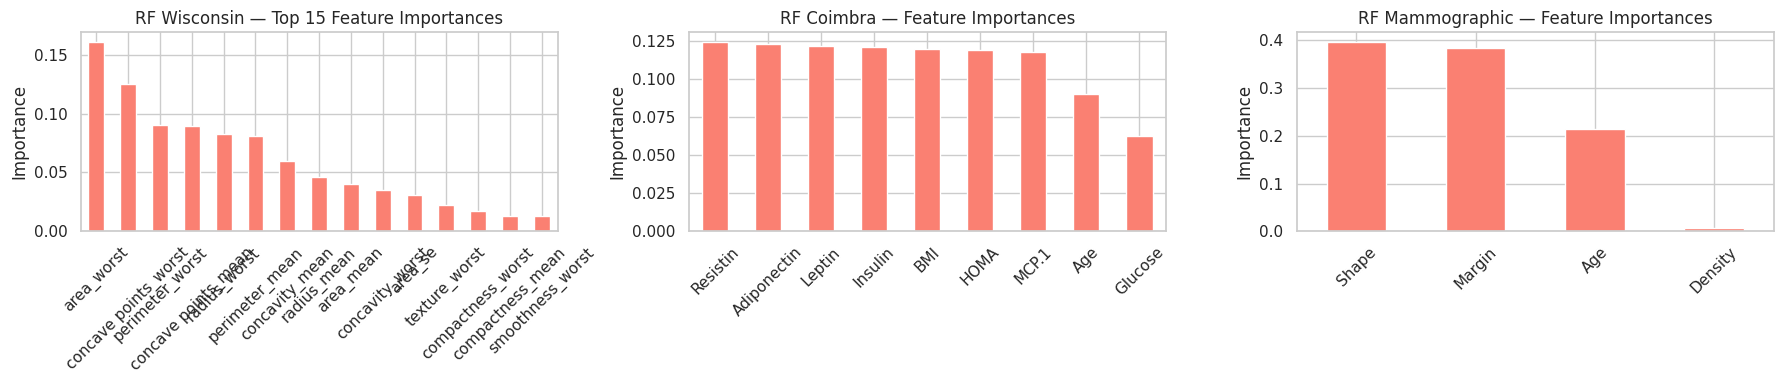

In [ ]:
# Feature importance plots
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

pd.Series(gs_rf1.best_estimator_.feature_importances_, index=X1_all.columns).sort_values(
    ascending=False).head(15).plot(kind="bar", ax=axes[0], color="salmon")
axes[0].set_title("RF Wisconsin — Top 15 Feature Importances")
axes[0].set_ylabel("Importance"); axes[0].tick_params(axis="x", rotation=45)

pd.Series(gs_rf2.best_estimator_.feature_importances_, index=X2_all.columns).sort_values(
    ascending=False).plot(kind="bar", ax=axes[1], color="salmon")
axes[1].set_title("RF Coimbra — Feature Importances")
axes[1].set_ylabel("Importance"); axes[1].tick_params(axis="x", rotation=45)

pd.Series(gs_rf3.best_estimator_.feature_importances_, index=X3_all.columns).sort_values(
    ascending=False).plot(kind="bar", ax=axes[2], color="salmon")
axes[2].set_title("RF Mammographic — Feature Importances")
axes[2].set_ylabel("Importance"); axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

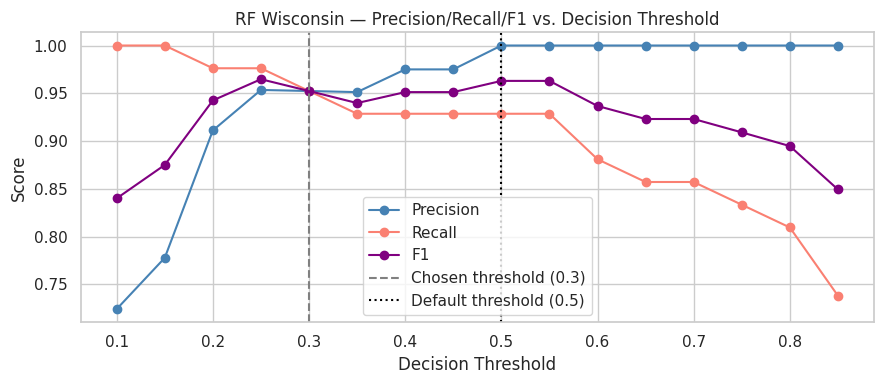

In [ ]:
# Threshold sensitivity - show precision/recall tradeoff for RF on DS1
# Justification for why 0.3 was chosen over the default 0.5
thresholds = np.arange(0.1, 0.9, 0.05)
precisions, recalls, f1s = [], [], []

for t in thresholds:
  y_pred_t = (y1_prob_rf_raw > t).astype(int)  # use raw proba before thresholding
  precisions.append(precision_score(y1_te, y_pred_t, zero_division=0))
  recalls.append(recall_score(y1_te, y_pred_t, zero_division=0))
  f1s.append(f1_score(y1_te, y_pred_t, zero_division=0))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, precisions, label="Precision", marker="o", color="steelblue")
ax.plot(thresholds, recalls, label="Recall", marker="o", color="salmon")
ax.plot(thresholds, f1s, label="F1", marker="o", color="purple")
ax.axvline(0.3, linestyle="--", color="gray", label="Chosen threshold (0.3)")
ax.axvline(0.5, linestyle=":", color="black", label="Default threshold (0.5)")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title("RF Wisconsin — Precision/Recall/F1 vs. Decision Threshold")
ax.legend()
plt.tight_layout()
plt.show()

## KNN

Classifies each sample by majority vote among its *k* nearest neighbours in feature space.

Feature scaling is essential (Euclidean distance is sensitive to scale). We tune *k*, distance weighting, and distance metric via `GridSearchCV`, independently for each dataset.

DS1 — Best params: {'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}
DS1 — Best CV recall: 0.9118

DS2 — Best params: {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'distance'}
DS2 — Best CV recall: 0.6762

DS3 — Best params: {'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'uniform'}
DS3 — Best CV recall: 0.8575

=== KNN — Wisconsin ===
  Accuracy : 0.9561
  Precision: 1.0000
  Recall   : 0.8810
  F1 Score : 0.9367
  ROC-AUC  : 0.9962

=== KNN — Coimbra ===
  Accuracy : 0.5312
  Precision: 0.5609
  Recall   : 0.7065
  F1 Score : 0.6254
  ROC-AUC  : 0.5242

=== KNN — Mammographic ===
  Accuracy : 0.7545
  Precision: 0.7326
  Recall   : 0.7778
  F1 Score : 0.7545
  ROC-AUC  : 0.8162


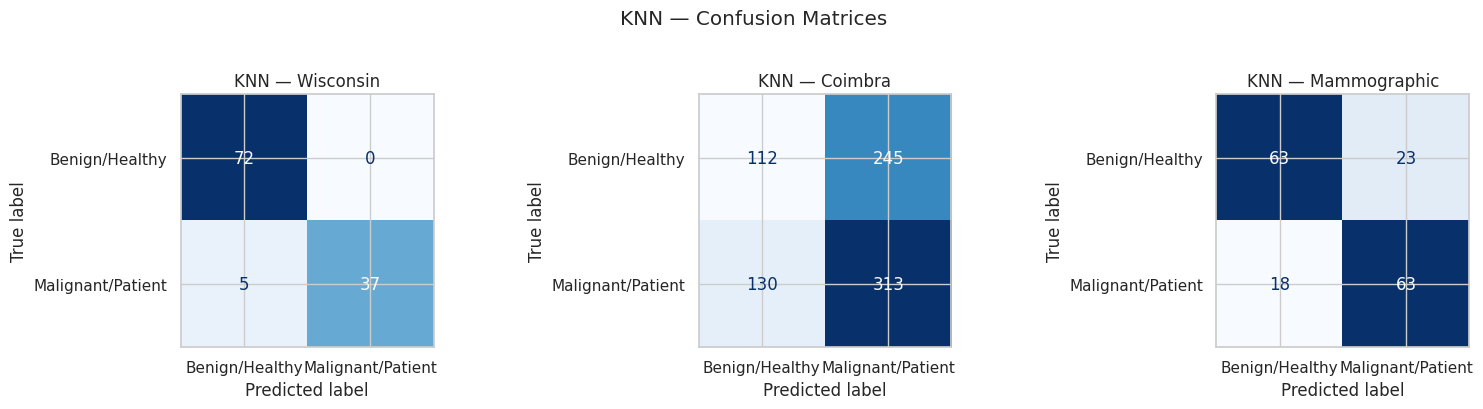

In [ ]:
# KNN
param_grid_knn = {
    "n_neighbors": [3, 5, 7, 9, 11, 15],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"],
}

# ── Dataset 1 ──────────────────────────────────
gs_knn1 = GridSearchCV(KNeighborsClassifier(), param_grid_knn, scoring=recall_malignant, cv=cv, n_jobs=-1)
gs_knn1.fit(X1_tr_s, y1_tr)
print("DS1 — Best params:", gs_knn1.best_params_)
print("DS1 — Best CV recall:", round(gs_knn1.best_score_, 4))

y1_pred_knn = gs_knn1.best_estimator_.predict(X1_te_s)
y1_prob_knn = gs_knn1.best_estimator_.predict_proba(X1_te_s)[:, 1]

# ── Dataset 2 ───────────────────────────────────
gs_knn2 = GridSearchCV(KNeighborsClassifier(), param_grid_knn, scoring=recall_malignant, cv=cv, n_jobs=-1)
gs_knn2.fit(X2_tr_s, y2_tr)
print("\nDS2 — Best params:", gs_knn2.best_params_)
print("DS2 — Best CV recall:", round(gs_knn2.best_score_, 4))

y2_pred_knn = gs_knn2.best_estimator_.predict(X2_te_s)
y2_prob_knn = gs_knn2.best_estimator_.predict_proba(X2_te_s)[:, 1]


# ── Dataset 3 ─────────────────────────────────────
gs_knn3 = GridSearchCV(KNeighborsClassifier(), param_grid_knn, scoring=recall_malignant, cv=cv, n_jobs=-1)
gs_knn3.fit(X3_tr_s, y3_tr)
print("\nDS3 — Best params:", gs_knn3.best_params_)
print("DS3 — Best CV recall:", round(gs_knn3.best_score_, 4))

y3_pred_knn = gs_knn3.best_estimator_.predict(X3_te_s)
y3_prob_knn = gs_knn3.best_estimator_.predict_proba(X3_te_s)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
res1_knn = evaluate_model("KNN — Wisconsin", y1_te, y1_pred_knn, y1_prob_knn, ax_cm=axes[0])
res2_knn = evaluate_model("KNN — Coimbra", y2_te, y2_pred_knn, y2_prob_knn, ax_cm=axes[1])
res3_knn = evaluate_model("KNN — Mammographic", y3_te, y3_pred_knn, y3_prob_knn, ax_cm=axes[2])
plt.suptitle("KNN — Confusion Matrices", y=1.02)
plt.tight_layout()
plt.show()

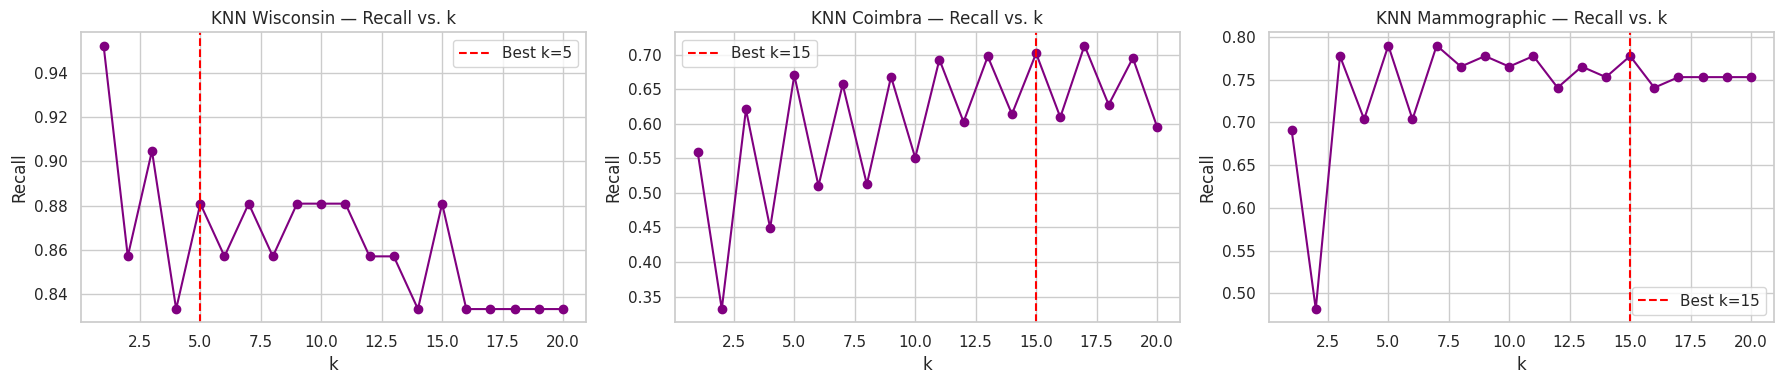

In [ ]:
# Recall vs k curves
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
k_vals = range(1, 21)

for ax, X_tr, X_te, y_tr, y_te, label, best_k in [
    (axes[0], X1_tr_s, X1_te_s, y1_tr, y1_te, "Wisconsin", gs_knn1.best_params_["n_neighbors"]),
    (axes[1], X2_tr_s, X2_te_s, y2_tr, y2_te, "Coimbra", gs_knn2.best_params_["n_neighbors"]),
    (axes[2], X3_tr_s, X3_te_s, y3_tr, y3_te, "Mammographic",gs_knn3.best_params_["n_neighbors"]),
]:
  recalls = [recall_score(y_te, KNeighborsClassifier(n_neighbors=k).fit(X_tr, y_tr).predict(X_te)) for k in k_vals]
  ax.plot(k_vals, recalls, marker="o", color="purple")
  ax.axvline(best_k, linestyle="--", color="red", label=f"Best k={best_k}")
  ax.set_title(f"KNN {label} — Recall vs. k")
  ax.set_xlabel("k"); ax.set_ylabel("Recall"); ax.legend()

plt.tight_layout()
plt.show()

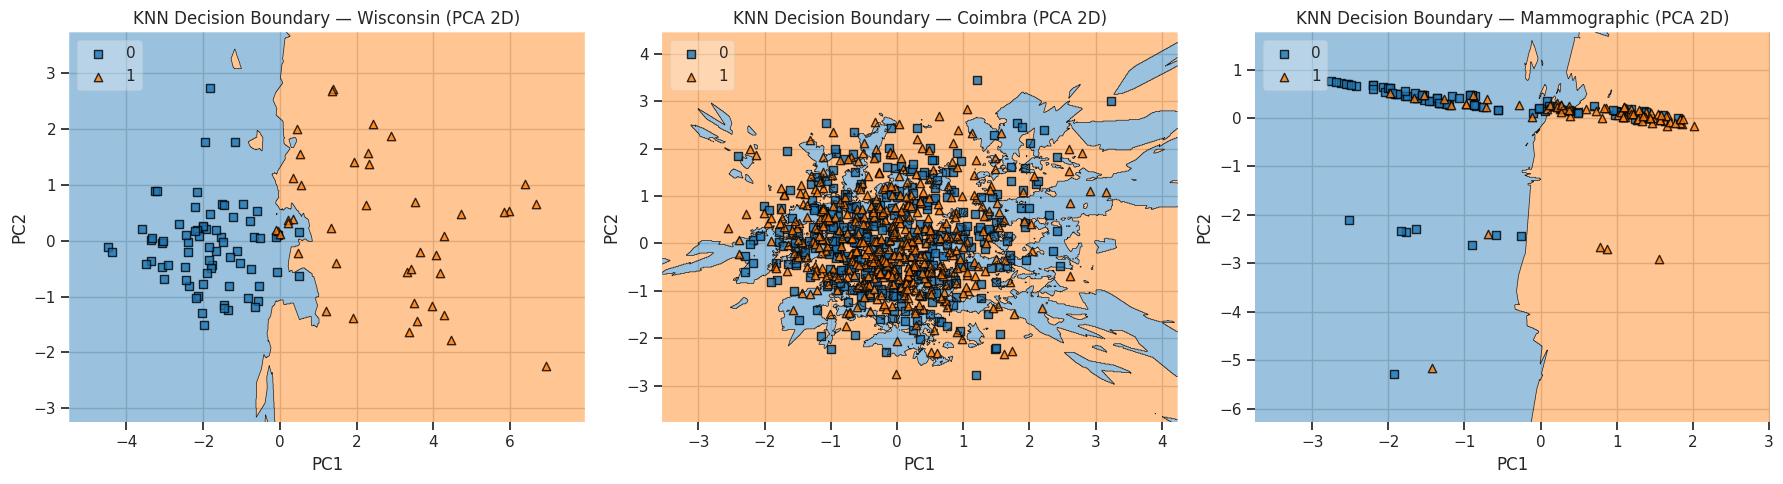

In [ ]:
# KNN decision boundaries (PCA 2D projection)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, X_tr, X_te, y_tr, y_te, label, best_k in [
    (axes[0], X1_tr_s, X1_te_s, y1_tr, y1_te, "Wisconsin", gs_knn1.best_params_["n_neighbors"]),
    (axes[1], X2_tr_s, X2_te_s, y2_tr, y2_te, "Coimbra",   gs_knn2.best_params_["n_neighbors"]),
    (axes[2], X3_tr_s, X3_te_s, y3_tr, y3_te, "Mammographic",   gs_knn3.best_params_["n_neighbors"]),
]:
  pca = PCA(n_components=2)
  X_tr_pca = pca.fit_transform(X_tr)
  X_te_pca = pca.transform(X_te)
  knn_pca = KNeighborsClassifier(n_neighbors=best_k).fit(X_tr_pca, y_tr)
  plt.sca(ax)
  plot_decision_regions(X_te_pca, y_te.values, clf=knn_pca, legend=2)
  ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
  ax.set_title(f"KNN Decision Boundary — {label} (PCA 2D)")
plt.tight_layout()
plt.show()

## SVM
Finds the maximum-margin hyperplane between classes. With an RBF kernel it handles non-linear boundaries.

`C` controls regularisation strength

`gamma` controls kernel width

Both datasets use balanced class weights.

DS1 — Best params: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
DS1 — Best CV recall: 0.9412

DS2 — Best params: {'C': 0.1, 'gamma': 0.001, 'kernel': 'rbf'}
DS2 — Best CV recall: 1.0

DS3 — Best params: {'C': 0.1, 'gamma': 0.001, 'kernel': 'rbf'}
DS3 — Best CV recall: 1.0

=== SVM — Wisconsin ===
  Accuracy : 0.9561
  Precision: 0.9512
  Recall   : 0.9286
  F1 Score : 0.9398
  ROC-AUC  : 0.9964

=== SVM — Coimbra ===
  Accuracy : 0.5537
  Precision: 0.5537
  Recall   : 1.0000
  F1 Score : 0.7128
  ROC-AUC  : 0.5057

=== SVM — Mammographic ===
  Accuracy : 0.5150
  Precision: 0.0000
  Recall   : 0.0000
  F1 Score : 0.0000
  ROC-AUC  : 0.8491


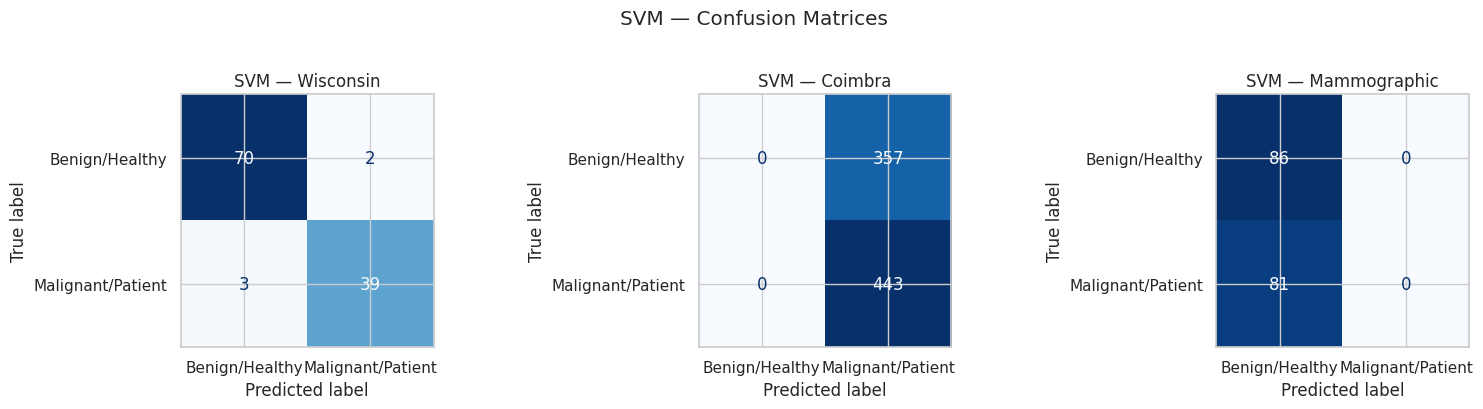

In [ ]:
# SVM
param_grid_svm = {
    'C' : [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.001],
    'kernel': ['rbf', 'linear'],
}

# ── Dataset 1 ───────────────────────────────────
gs_svm1 = GridSearchCV(SVC(probability=True, class_weight="balanced", random_state=RANDOM_STATE),
                       param_grid_svm, scoring=recall_malignant, cv=cv, n_jobs=-1)
gs_svm1.fit(X1_tr_s, y1_tr)
print("DS1 — Best params:", gs_svm1.best_params_)
print("DS1 — Best CV recall:", round(gs_svm1.best_score_, 4))

y1_pred_svm = gs_svm1.best_estimator_.predict(X1_te_s)
y1_prob_svm = gs_svm1.best_estimator_.predict_proba(X1_te_s)[:, 1]

# ── Dataset 2 ───────────────────────────────────
gs_svm2 = GridSearchCV(SVC(probability=True, class_weight="balanced", random_state=RANDOM_STATE),
                       param_grid_svm, scoring=recall_malignant, cv=cv, n_jobs=-1)
gs_svm2.fit(X2_tr_s, y2_tr)
print("\nDS2 — Best params:", gs_svm2.best_params_)
print("DS2 — Best CV recall:", round(gs_svm2.best_score_, 4))

y2_pred_svm = gs_svm2.best_estimator_.predict(X2_te_s)
y2_prob_svm = gs_svm2.best_estimator_.predict_proba(X2_te_s)[:, 1]

# ── Dataset 3 ────────────────────────────────────
gs_svm3 = GridSearchCV(SVC(probability=True, class_weight="balanced", random_state=RANDOM_STATE),
                       param_grid_svm, scoring=recall_malignant, cv=cv, n_jobs=-1)
gs_svm3.fit(X3_tr_s, y3_tr)
print("\nDS3 — Best params:", gs_svm3.best_params_)
print("DS3 — Best CV recall:", round(gs_svm3.best_score_, 4))

y3_pred_svm = gs_svm3.best_estimator_.predict(X3_te_s)
y3_prob_svm = gs_svm3.best_estimator_.predict_proba(X3_te_s)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
res1_svm = evaluate_model("SVM — Wisconsin", y1_te, y1_pred_svm, y1_prob_svm, ax_cm=axes[0])
res2_svm = evaluate_model("SVM — Coimbra", y2_te, y2_pred_svm, y2_prob_svm, ax_cm=axes[1])
res3_svm = evaluate_model("SVM — Mammographic", y3_te, y3_pred_svm, y3_prob_svm, ax_cm=axes[2])
plt.suptitle("SVM — Confusion Matrices", y=1.02)
plt.tight_layout()
plt.show()

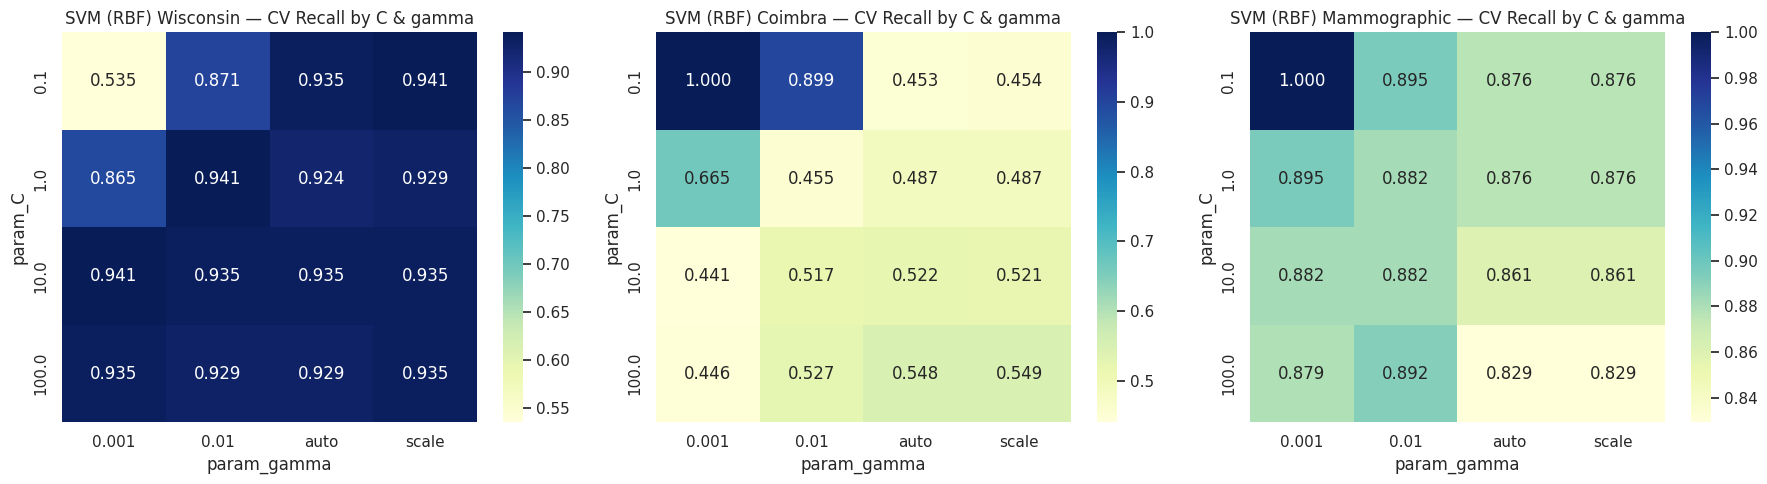

In [ ]:
# GridSearch heatmaps - RBF kernel recall scores
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, gs, label in [(axes[0], gs_svm1, "Wisconsin"), (axes[1], gs_svm2, "Coimbra"), (axes[2], gs_svm3, "Mammographic")]:
  cv_df = pd.DataFrame(gs.cv_results_)
  rbf = cv_df[cv_df["param_kernel"] == "rbf"]
  pivot = rbf.pivot_table(index="param_C", columns="param_gamma", values="mean_test_score")
  sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax)
  ax.set_title(f"SVM (RBF) {label} — CV Recall by C & gamma")

plt.tight_layout()
plt.show()

## Neural Network (MLP)
Multi-Layer Perceptron with two hidden layers.

We tune layer sizes, learning rate, and regularisation (`alpha`) via `GridSearchCV`. The network uses ReLU activations and early stopping to prevent overfitting. Loss curves are plotted to visualise convergence.

DS1 — Best params: {'alpha': 0.0001, 'hidden_layer_sizes': (64, 32), 'learning_rate_init': 0.001}
DS1 — Best CV recall: 0.9471

DS2 — Best params: {'alpha': 0.0001, 'hidden_layer_sizes': (64, 64, 32), 'learning_rate_init': 0.001}
DS2 — Best CV recall: 0.9431

DS3 — Best params: {'alpha': 0.0001, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.001}
DS3 — Best CV recall: 0.8545

=== MLP — Wisconsin ===
  Accuracy : 0.9561
  Precision: 0.9512
  Recall   : 0.9286
  F1 Score : 0.9398
  ROC-AUC  : 0.9934

=== MLP — Coimbra ===
  Accuracy : 0.5513
  Precision: 0.5534
  Recall   : 0.9819
  F1 Score : 0.7079
  ROC-AUC  : 0.5417

=== MLP — Mammographic ===
  Accuracy : 0.7665
  Precision: 0.7763
  Recall   : 0.7284
  F1 Score : 0.7516
  ROC-AUC  : 0.8419


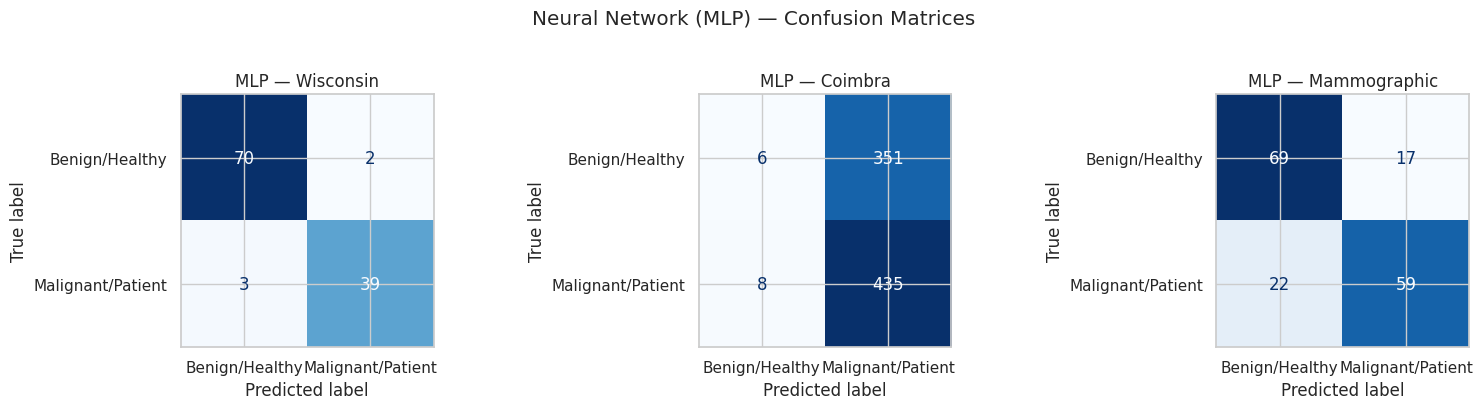

In [ ]:
from sklearn.neural_network import MLPClassifier
param_grid_mlp = {
    "hidden_layer_sizes": [(64, 32), (128, 64), (64, 64, 32)],
    "alpha" : [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01],
}

# ── Dataset 1 ─────────────────────────────────────
gs_mlp1 = GridSearchCV(MLPClassifier(activation="relu", max_iter=1000, early_stopping=True, random_state=RANDOM_STATE),
                       param_grid_mlp, scoring=recall_malignant, cv=cv, n_jobs=-1, verbose=0)
gs_mlp1.fit(X1_tr_s, y1_tr)
print("DS1 — Best params:", gs_mlp1.best_params_)
print("DS1 — Best CV recall:", round(gs_mlp1.best_score_, 4))

y1_pred_mlp = gs_mlp1.best_estimator_.predict(X1_te_s)
y1_prob_mlp = gs_mlp1.best_estimator_.predict_proba(X1_te_s)[:, 1]

# ── Dataset 2 ───────────────────────────────────────
gs_mlp2 = GridSearchCV(MLPClassifier(activation="relu", max_iter=1000, early_stopping=True, random_state=RANDOM_STATE),
                       param_grid_mlp, scoring=recall_malignant, cv=cv, n_jobs=-1, verbose=0)
gs_mlp2.fit(X2_tr_s, y2_tr)
print("\nDS2 — Best params:", gs_mlp2.best_params_)
print("DS2 — Best CV recall:", round(gs_mlp2.best_score_, 4))

y2_pred_mlp = gs_mlp2.best_estimator_.predict(X2_te_s)
y2_prob_mlp = gs_mlp2.best_estimator_.predict_proba(X2_te_s)[:, 1]

# ── Dataset 3 ─────────────────────────────────────────
gs_mlp3 = GridSearchCV(MLPClassifier(activation="relu", max_iter=1000, early_stopping=True, random_state=RANDOM_STATE),
                       param_grid_mlp, scoring=recall_malignant, cv=cv, n_jobs=-1, verbose=0)
gs_mlp3.fit(X3_tr_s, y3_tr)
print("\nDS3 — Best params:", gs_mlp3.best_params_)
print("DS3 — Best CV recall:", round(gs_mlp3.best_score_, 4))

y3_pred_mlp = gs_mlp3.best_estimator_.predict(X3_te_s)
y3_prob_mlp = gs_mlp3.best_estimator_.predict_proba(X3_te_s)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
res1_mlp = evaluate_model("MLP — Wisconsin", y1_te, y1_pred_mlp, y1_prob_mlp, ax_cm=axes[0])
res2_mlp = evaluate_model("MLP — Coimbra", y2_te, y2_pred_mlp, y2_prob_mlp, ax_cm=axes[1])
res3_mlp = evaluate_model("MLP — Mammographic", y3_te, y3_pred_mlp, y3_prob_mlp, ax_cm=axes[2])
plt.suptitle("Neural Network (MLP) — Confusion Matrices", y=1.02)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


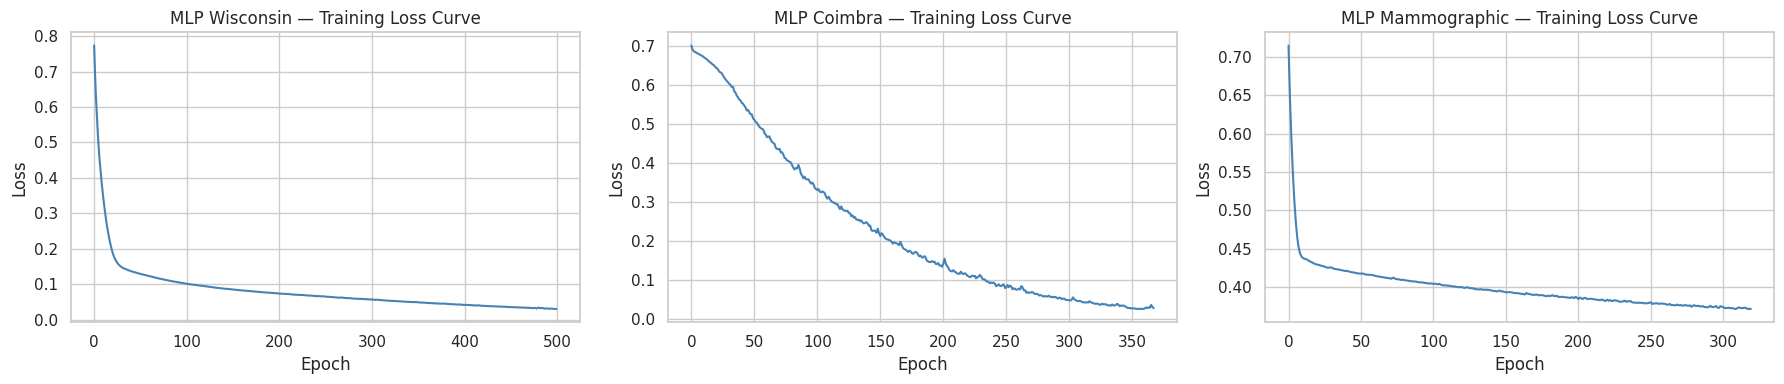

In [ ]:
# MLP training loss curves
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, gs, X_tr, y_tr, label in [
    (axes[0], gs_mlp1, X1_tr_s, y1_tr, "Wisconsin"),
    (axes[1], gs_mlp2, X2_tr_s, y2_tr, "Coimbra"),
    (axes[2], gs_mlp3, X3_tr_s, y3_tr, "Mammographic"),
]:
  mlp_curve = MLPClassifier(**{**gs.best_params_, "activation": "relu", "max_iter": 500, "random_state": RANDOM_STATE})
  mlp_curve.fit(X_tr, y_tr)
  ax.plot(mlp_curve.loss_curve_, color="steelblue")
  ax.set_title(f"MLP {label} — Training Loss Curve")
  ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")

plt.tight_layout()
plt.show()

## Gradient Boosting
Boosting builds an ensemble sequentially: each tree corrects the residual errors of all previous trees. This contrasts with Random Forest's parallel bagging; boosting reduces bias while bagging reduces variance.

We use sklearn's `GradientBoostingClassifier`, which implements the original Friedman (2001) gradient boosting algorithm.

Key hyperparameters tuned:
- `n_estimators` - number of boosting stages (trees)
- `max_depth` - depth of each individual tree (kept shallow: weak learners work better)
- `learning_rate` - shrinkage applied to each tree's contribution (smaller = more conservative)
- `subsample` - fraction of training samples used per tree (< 1.0 adds stochastic variance reduction)

DS1 — Best params: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200, 'subsample': 0.8}
DS1 — Best CV recall: 0.9294

DS2 — Best params: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 100, 'subsample': 1.0}
DS2 — Best CV recall: 0.9109

DS3 — Best params: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100, 'subsample': 1.0}
DS3 — Best CV recall: 0.8731

=== GradBoost — Wisconsin ===
  Accuracy : 0.9649
  Precision: 1.0000
  Recall   : 0.9048
  F1 Score : 0.9500
  ROC-AUC  : 0.9940

=== GradBoost — Coimbra ===
  Accuracy : 0.5625
  Precision: 0.5622
  Recall   : 0.9481
  F1 Score : 0.7059
  ROC-AUC  : 0.5031

=== GradBoost — Mammographic ===
  Accuracy : 0.7844
  Precision: 0.7778
  Recall   : 0.7778
  F1 Score : 0.7778
  ROC-AUC  : 0.8497


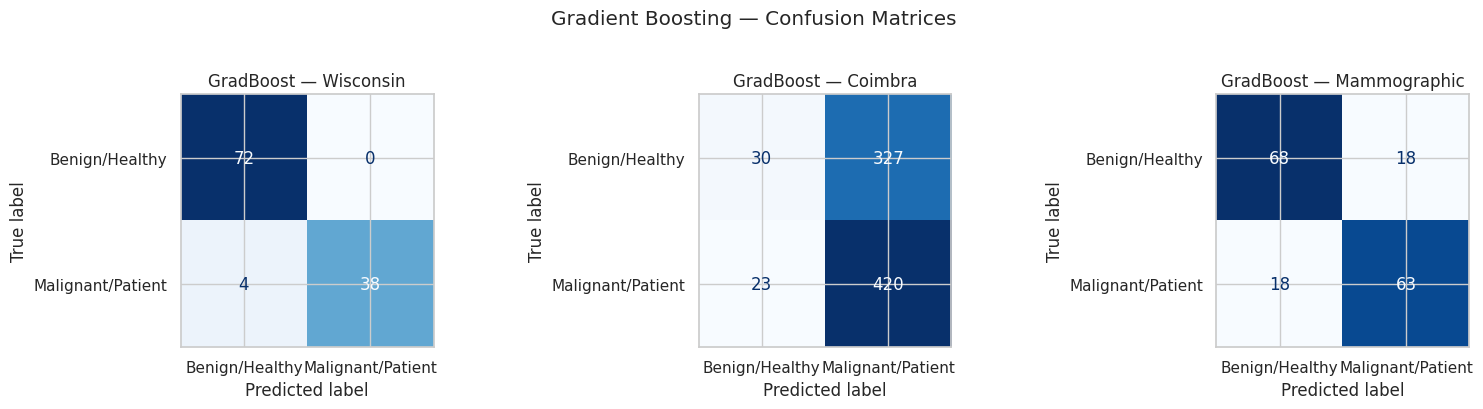

In [ ]:
# Gradient Boosting - all 3 datasets
param_grid_gb = {
    "n_estimators": [100, 200],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.8, 1.0],
}

# ── Dataset 1 ──────────────────────────────
gs_gb1 = GridSearchCV(GradientBoostingClassifier(random_state=RANDOM_STATE),
                      param_grid_gb, scoring=recall_malignant, cv=cv, n_jobs=-1, verbose=0
)
gs_gb1.fit(X1_tr_s, y1_tr)
print("DS1 — Best params:", gs_gb1.best_params_)
print("DS1 — Best CV recall:", round(gs_gb1.best_score_, 4))

y1_pred_gb = gs_gb1.best_estimator_.predict(X1_te_s)
y1_prob_gb = gs_gb1.best_estimator_.predict_proba(X1_te_s)[:, 1]

# ── Dataset 2 ───────────────────────────────
gs_gb2 = GridSearchCV(GradientBoostingClassifier(random_state=RANDOM_STATE),
                      param_grid_gb, scoring=recall_malignant, cv=cv, n_jobs=-1, verbose=0
)
gs_gb2.fit(X2_tr_s, y2_tr)
print("\nDS2 — Best params:", gs_gb2.best_params_)
print("DS2 — Best CV recall:", round(gs_gb2.best_score_, 4))

y2_pred_gb = gs_gb2.best_estimator_.predict(X2_te_s)
y2_prob_gb = gs_gb2.best_estimator_.predict_proba(X2_te_s)[:, 1]

# ── Dataset 3 ─────────────────────────────────
gs_gb3 = GridSearchCV(GradientBoostingClassifier(random_state=RANDOM_STATE),
                      param_grid_gb, scoring=recall_malignant, cv=cv, n_jobs=-1, verbose=0
)
gs_gb3.fit(X3_tr_s, y3_tr)
print("\nDS3 — Best params:", gs_gb3.best_params_)
print("DS3 — Best CV recall:", round(gs_gb3.best_score_, 4))

y3_pred_gb = gs_gb3.best_estimator_.predict(X3_te_s)
y3_prob_gb = gs_gb3.best_estimator_.predict_proba(X3_te_s)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
res1_gb = evaluate_model("GradBoost — Wisconsin", y1_te, y1_pred_gb, y1_prob_gb, ax_cm=axes[0])
res2_gb = evaluate_model("GradBoost — Coimbra", y2_te, y2_pred_gb, y2_prob_gb, ax_cm=axes[1])
res3_gb = evaluate_model("GradBoost — Mammographic", y3_te, y3_pred_gb, y3_prob_gb, ax_cm=axes[2])
plt.suptitle("Gradient Boosting — Confusion Matrices", y=1.02)
plt.tight_layout()
plt.show()

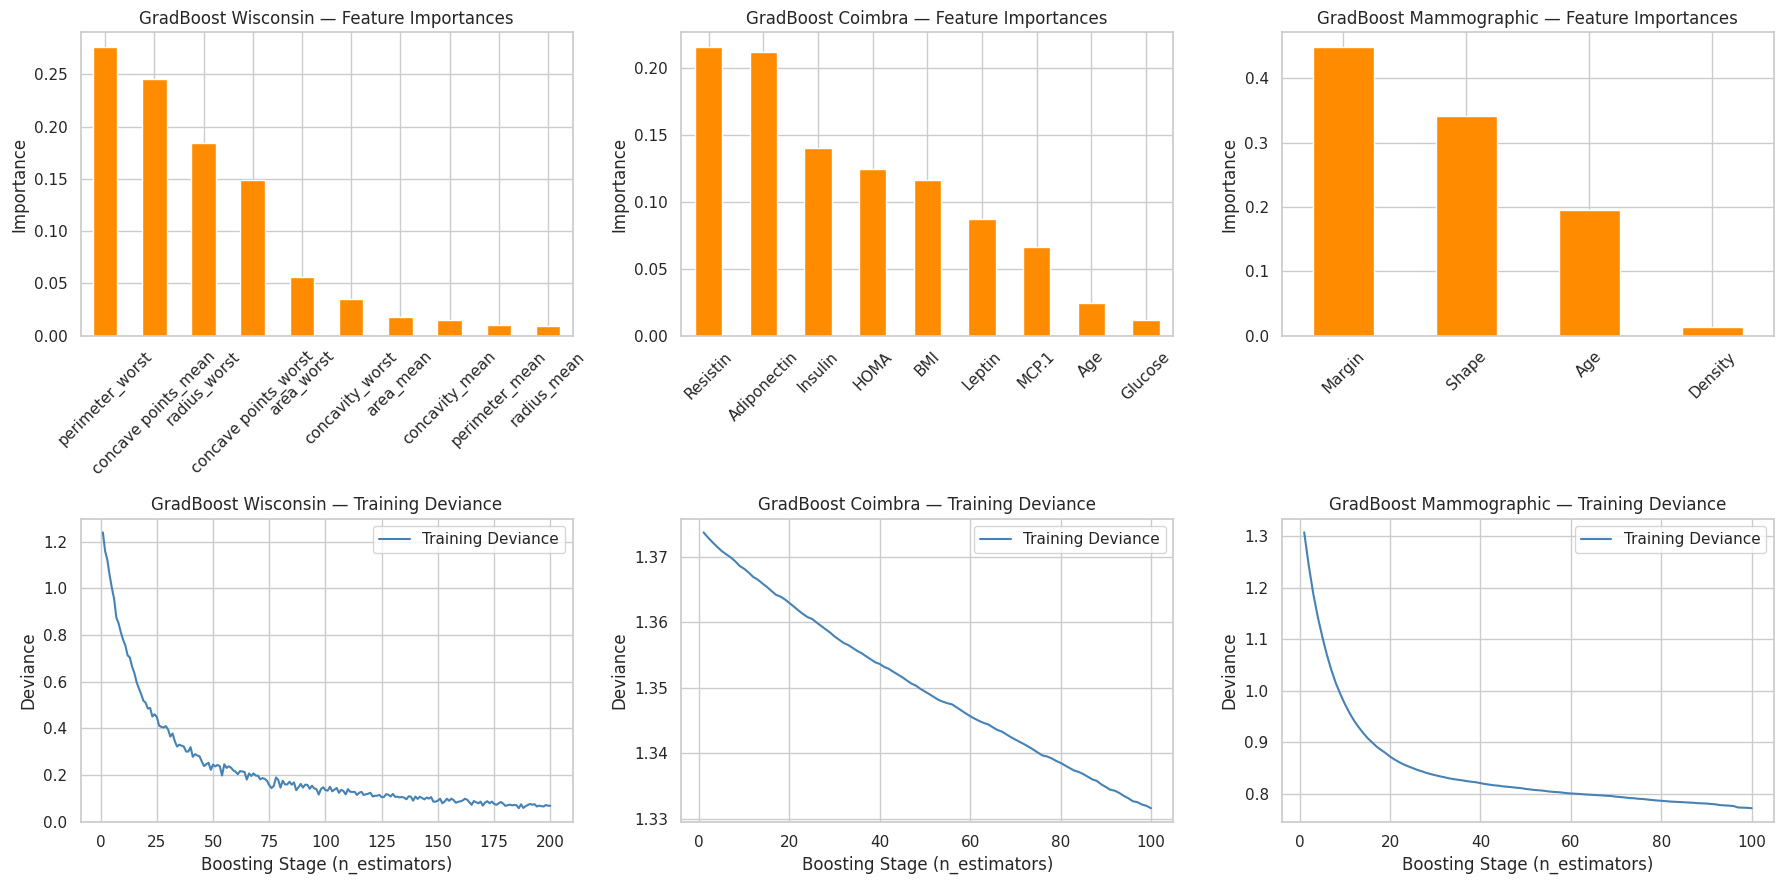

In [ ]:
# Gradient Boosting: feature importances + training deviance (loss) curve
fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for col, (gs, label, feat_names) in enumerate([
    (gs_gb1, "Wisconsin", top_features1),
    (gs_gb2, "Coimbra", list(X2_all.columns)),
    (gs_gb3, "Mammographic", list(X3_all.columns)),
]):
  best = gs.best_estimator_

  # Feature importances
  pd.Series(best.feature_importances_, index=feat_names).sort_values(ascending=False).plot(kind="bar", ax=axes[0, col], color="darkorange")
  axes[0, col].set_title(f"GradBoost {label} — Feature Importances")
  axes[0, col].set_ylabel("Importance"); axes[0, col].tick_params(axis="x", rotation=45)

  # Training deviance (loss) curve — shows how boosting converges
  train_scores = best.train_score_
  axes[1, col].plot(np.arange(len(train_scores)) + 1, train_scores, label="Training Deviance", color="steelblue")
  axes[1, col].set_xlabel("Boosting Stage (n_estimators)")
  axes[1, col].set_ylabel("Deviance")
  axes[1, col].set_title(f"GradBoost {label} — Training Deviance")
  axes[1, col].legend()

plt.tight_layout()
plt.show()

## Stacking Ensemble
Stacking trains multiple base learners, then trains a meta-learner on their predictions. This allows the meta-learner to learn which base model to trust most for different regions of the input space.

We stack LR, RF, KNN, SVM, and MLP with Logistic Regression as the meta-learner, using `passthrough=True` so the original features are also passed to the meta-learner.

The stacking ensemble uses the top-10 scaled features for all base learners, including RF.
This differs from the standalone RF evaluation (which used all 30 features) because the StackingClassifier requires a single consistent input matrix shared across all base learners.

Tradeoff: standalone RF sees more signal; stacked RF is constrained to the same feature space as LR, KNN, SVM, and MLP for a fair apples-to-apples comparison at the ensemble level.


=== Stacking — Wisconsin ===
  Accuracy : 0.9737
  Precision: 1.0000
  Recall   : 0.9286
  F1 Score : 0.9630
  ROC-AUC  : 0.9980

=== Stacking — Coimbra ===
  Accuracy : 0.5550
  Precision: 0.5550
  Recall   : 0.9910
  F1 Score : 0.7115
  ROC-AUC  : 0.5143

=== Stacking — Mammographic ===
  Accuracy : 0.7844
  Precision: 0.7778
  Recall   : 0.7778
  F1 Score : 0.7778
  ROC-AUC  : 0.8537


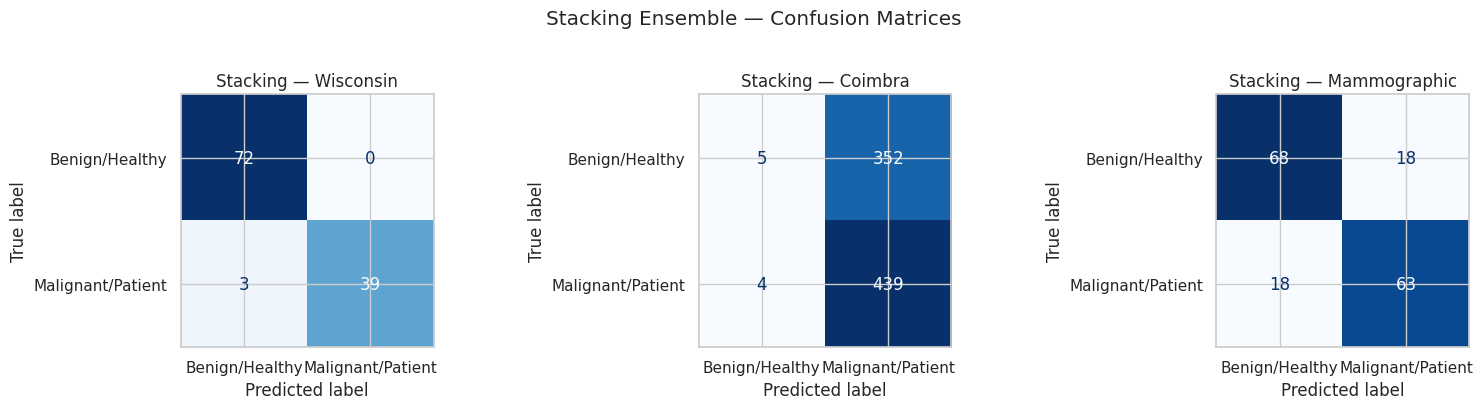

In [ ]:
# Use best hyperparameters found above for each base learner
def make_base_learners(gs_rf, gs_knn, gs_svm, gs_mlp):
  return [
      ("lr",  LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
      ("rf",  RandomForestClassifier(**gs_rf.best_params_,  class_weight="balanced", random_state=RANDOM_STATE)),
      ("knn", KNeighborsClassifier(**gs_knn.best_params_)),
      ("svm", SVC(probability=True, class_weight="balanced", random_state=RANDOM_STATE, **gs_svm.best_params_)),
      ("mlp", MLPClassifier(**gs_mlp.best_params_, activation="relu", max_iter=1000, random_state=RANDOM_STATE)),
  ]

# ── Dataset 1 ────────────────────────────────────────────
stack1 = StackingClassifier(
    estimators=make_base_learners(gs_rf1, gs_knn1, gs_svm1, gs_mlp1),
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5, passthrough=True, n_jobs=-1)
stack1.fit(X1_tr_s, y1_tr)
y1_pred_stack = stack1.predict(X1_te_s)
y1_prob_stack = stack1.predict_proba(X1_te_s)[:, 1]

# ── Dataset 2 ─────────────────────────────────────────────
stack2 = StackingClassifier(
    estimators=make_base_learners(gs_rf2, gs_knn2, gs_svm2, gs_mlp2),
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5, passthrough=True, n_jobs=-1)
stack2.fit(X2_tr_s, y2_tr)
y2_pred_stack = stack2.predict(X2_te_s)
y2_prob_stack = stack2.predict_proba(X2_te_s)[:, 1]

# ── Dataset 3 ─────────────────────────────────────────────
stack3 = StackingClassifier(
    estimators=make_base_learners(gs_rf3, gs_knn3, gs_svm3, gs_mlp3),
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5, passthrough=True, n_jobs=-1)
stack3.fit(X3_tr_s, y3_tr)
y3_pred_stack = stack3.predict(X3_te_s)
y3_prob_stack = stack3.predict_proba(X3_te_s)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
res1_stack = evaluate_model("Stacking — Wisconsin", y1_te, y1_pred_stack, y1_prob_stack, ax_cm=axes[0])
res2_stack = evaluate_model("Stacking — Coimbra", y2_te, y2_pred_stack, y2_prob_stack, ax_cm=axes[1])
res3_stack = evaluate_model("Stacking — Mammographic", y3_te, y3_pred_stack, y3_prob_stack, ax_cm=axes[2])
plt.suptitle("Stacking Ensemble — Confusion Matrices", y=1.02)
plt.tight_layout()
plt.show()

## XGBoost

XGBoost extends gradient boosting with explicit L1/L2 regularization in the objective function,
column and row subsampling (like Random Forest), and a more efficient split-finding algorithm.

Key differences from sklearn's GradientBoostingClassifier:
- **`scale_pos_weight`**: directly handles class imbalance by up-weighting the minority class
- **`reg_alpha` / `reg_lambda`**: L1/L2 regularization on leaf weights (GradBoost has neither)
- **`colsample_bytree`**: randomly samples features per tree (combines boosting + bagging)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:53:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


DS1 — Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
DS1 — Best CV recall: 0.9412


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:53:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



DS2 — Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
DS2 — Best CV recall: 0.0


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:53:57] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



DS3 — Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
DS3 — Best CV recall: 0.8761

=== XGBoost — Wisconsin ===
  Accuracy : 0.9474
  Precision: 0.9737
  Recall   : 0.8810
  F1 Score : 0.9250
  ROC-AUC  : 0.9950

=== XGBoost — Coimbra ===
  Accuracy : 0.4462
  Precision: 0.0000
  Recall   : 0.0000
  F1 Score : 0.0000
  ROC-AUC  : 0.5000

=== XGBoost — Mammographic ===
  Accuracy : 0.7725
  Precision: 0.7654
  Recall   : 0.7654
  F1 Score : 0.7654
  ROC-AUC  : 0.8539


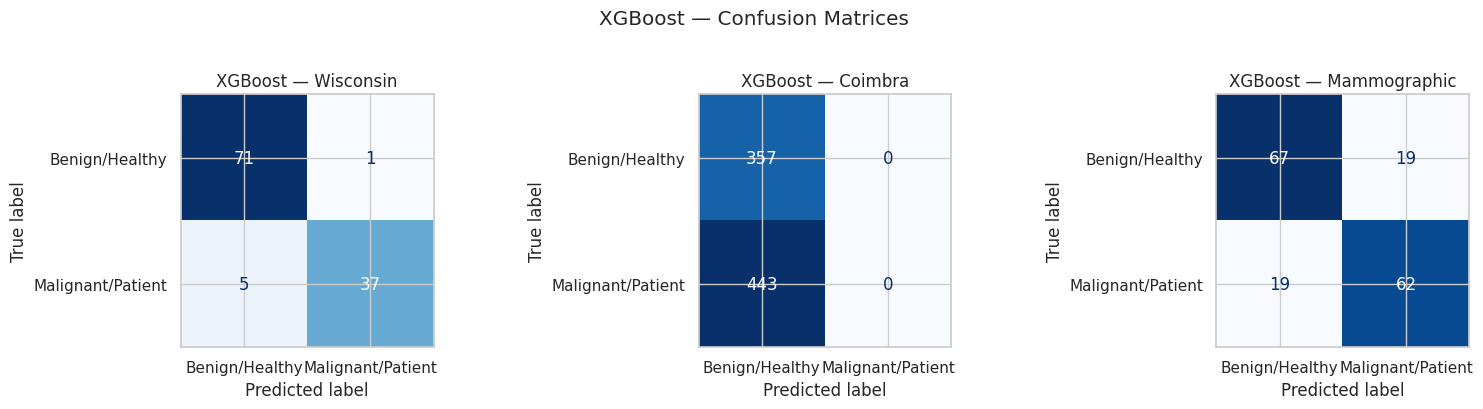

In [ ]:
# !pip install xgboost  # run once if not installed

# scale_pos_weight = (# negative samples) / (# positive samples) — corrects class imbalance
scale1 = int((y1_tr == 0).sum() / (y1_tr == 1).sum())
scale2 = int((y2_tr == 0).sum() / (y2_tr == 1).sum())
scale3 = int((y3_tr == 0).sum() / (y3_tr == 1).sum())

param_grid_xgb = {
    "n_estimators":     [100, 200],
    "max_depth":        [3, 5, 7],
    "learning_rate":    [0.05, 0.1, 0.2],
    "subsample":        [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

# ── Dataset 1 ────────────────────────────
gs_xgb1 = GridSearchCV(
    XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE,
                  scale_pos_weight=scale1, use_label_encoder=False),
    param_grid_xgb, scoring=recall_malignant, cv=cv, n_jobs=-1, verbose=0)
gs_xgb1.fit(X1_tr_s, y1_tr)
print("DS1 — Best params:", gs_xgb1.best_params_)
print("DS1 — Best CV recall:", round(gs_xgb1.best_score_, 4))

y1_pred_xgb = gs_xgb1.best_estimator_.predict(X1_te_s)
y1_prob_xgb = gs_xgb1.best_estimator_.predict_proba(X1_te_s)[:, 1]

# ── Dataset 2 ─────────────────────────────
gs_xgb2 = GridSearchCV(
    XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE,
                  scale_pos_weight=scale2, use_label_encoder=False),
    param_grid_xgb, scoring=recall_malignant, cv=cv, n_jobs=-1, verbose=0)
gs_xgb2.fit(X2_tr_s, y2_tr)
print("\nDS2 — Best params:", gs_xgb2.best_params_)
print("DS2 — Best CV recall:", round(gs_xgb2.best_score_, 4))

y2_pred_xgb = gs_xgb2.best_estimator_.predict(X2_te_s)
y2_prob_xgb = gs_xgb2.best_estimator_.predict_proba(X2_te_s)[:, 1]

# ── Dataset 3 ───────────────────────────────
gs_xgb3 = GridSearchCV(
    XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE,
                  scale_pos_weight=scale3, use_label_encoder=False),
    param_grid_xgb, scoring=recall_malignant, cv=cv, n_jobs=-1, verbose=0)
gs_xgb3.fit(X3_tr_s, y3_tr)
print("\nDS3 — Best params:", gs_xgb3.best_params_)
print("DS3 — Best CV recall:", round(gs_xgb3.best_score_, 4))

y3_pred_xgb = gs_xgb3.best_estimator_.predict(X3_te_s)
y3_prob_xgb = gs_xgb3.best_estimator_.predict_proba(X3_te_s)[:, 1]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
res1_xgb = evaluate_model("XGBoost — Wisconsin", y1_te, y1_pred_xgb, y1_prob_xgb, ax_cm=axes[0])
res2_xgb = evaluate_model("XGBoost — Coimbra", y2_te, y2_pred_xgb, y2_prob_xgb, ax_cm=axes[1])
res3_xgb = evaluate_model("XGBoost — Mammographic", y3_te, y3_pred_xgb, y3_prob_xgb, ax_cm=axes[2])
plt.suptitle("XGBoost — Confusion Matrices", y=1.02)
plt.tight_layout()
plt.show()

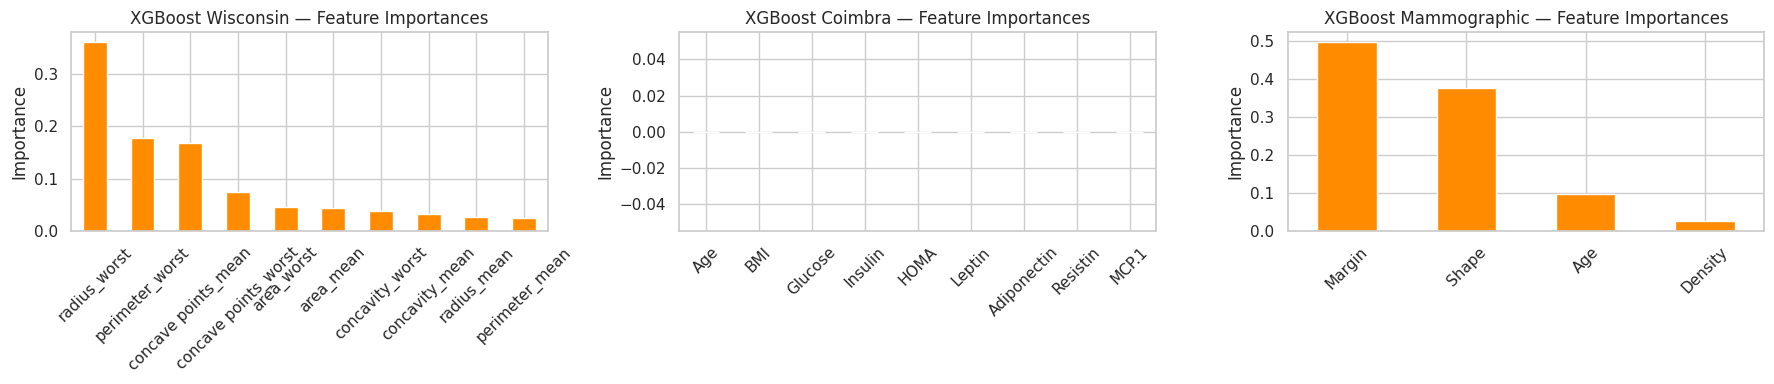

In [ ]:
# XGBoost feature importances
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

pd.Series(gs_xgb1.best_estimator_.feature_importances_, index=top_features1).sort_values(
    ascending=False).plot(kind="bar", ax=axes[0], color="darkorange")
axes[0].set_title("XGBoost Wisconsin — Feature Importances")
axes[0].set_ylabel("Importance"); axes[0].tick_params(axis="x", rotation=45)

pd.Series(gs_xgb2.best_estimator_.feature_importances_, index=X2_all.columns).sort_values(
    ascending=False).plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("XGBoost Coimbra — Feature Importances")
axes[1].set_ylabel("Importance"); axes[1].tick_params(axis="x", rotation=45)

pd.Series(gs_xgb3.best_estimator_.feature_importances_, index=X3_all.columns).sort_values(
    ascending=False).plot(kind="bar", ax=axes[2], color="darkorange")
axes[2].set_title("XGBoost Mammographic — Feature Importances")
axes[2].set_ylabel("Importance"); axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Model Comparison

Summary across all models and both datasets.

Primary metric is recall, since a false negative (missed cancer) is clinically more harmful than a false positive.

In [ ]:
ds1_results = [res1_lr, res1_rf, res1_knn, res1_svm, res1_mlp, res1_gb, res1_xgb, res1_stack]
ds2_results = [res2_lr, res2_rf, res2_knn, res2_svm, res2_mlp, res2_gb, res2_xgb, res2_stack]
ds3_results = [res3_lr, res3_rf, res3_knn, res3_svm, res3_mlp, res3_gb, res3_xgb, res3_stack]

df_ds1 = pd.DataFrame(ds1_results).set_index("name").round(4)
df_ds2 = pd.DataFrame(ds2_results).set_index("name").round(4)
df_ds3 = pd.DataFrame(ds3_results).set_index("name").round(4)

for label, df_res in [("Dataset 1 (Wisconsin)", df_ds1), ("Dataset 2 (Coimbra)", df_ds2), ("Dataset 3 (Mammographic)", df_ds3)]:
  print(f"\n=== {label} ===")
  print(df_res.to_string())


=== Dataset 1 (Wisconsin) ===
                       accuracy  precision  recall      f1     auc
name                                                              
LR — Wisconsin           0.9561     0.9744  0.9048  0.9383  0.9974
RF — Wisconsin           0.9649     0.9524  0.9524  0.9524  0.9967
KNN — Wisconsin          0.9561     1.0000  0.8810  0.9367  0.9962
SVM — Wisconsin          0.9561     0.9512  0.9286  0.9398  0.9964
MLP — Wisconsin          0.9561     0.9512  0.9286  0.9398  0.9934
GradBoost — Wisconsin    0.9649     1.0000  0.9048  0.9500  0.9940
XGBoost — Wisconsin      0.9474     0.9737  0.8810  0.9250  0.9950
Stacking — Wisconsin     0.9737     1.0000  0.9286  0.9630  0.9980

=== Dataset 2 (Coimbra) ===
                     accuracy  precision  recall      f1     auc
name                                                            
LR — Coimbra           0.5525     0.5532  0.9977  0.7118  0.4947
RF — Coimbra           0.5250     0.5540  0.7291  0.6296  0.5057
KNN — Coim

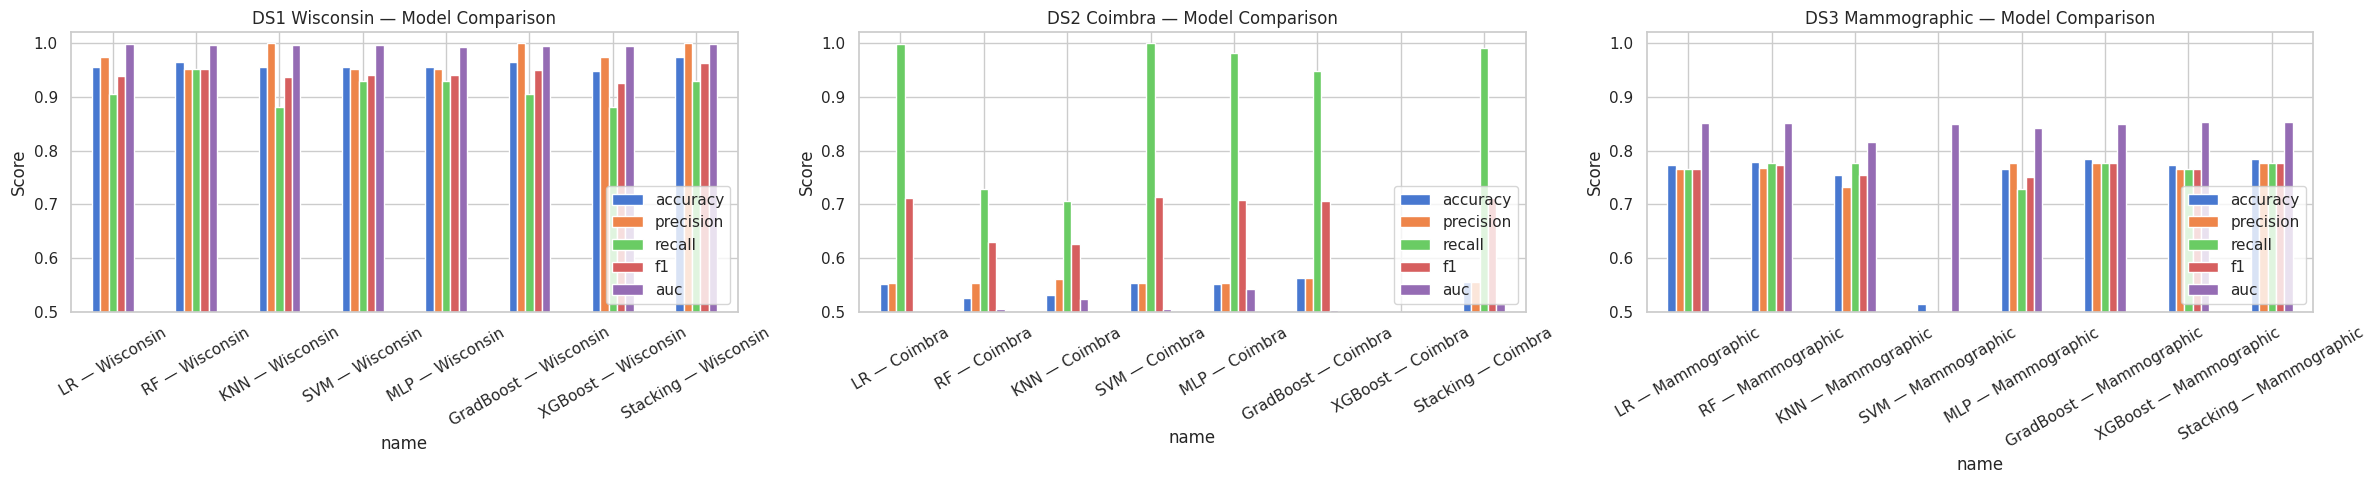

In [ ]:
# Bar chart comparison
metrics = ["accuracy", "precision", "recall", "f1", "auc"]
fig, axes = plt.subplots(1, 3, figsize=(24, 5))

for ax, df_res, title in [
    (axes[0], df_ds1, "DS1 Wisconsin — Model Comparison"),
    (axes[1], df_ds2, "DS2 Coimbra — Model Comparison"),
    (axes[2], df_ds3, "DS3 Mammographic — Model Comparison"),
]:
  df_res[metrics].plot(kind="bar", ax=ax, ylim=(0.5, 1.02))
  ax.set_title(title)
  ax.set_ylabel("Score"); ax.tick_params(axis="x", rotation=30)
  ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

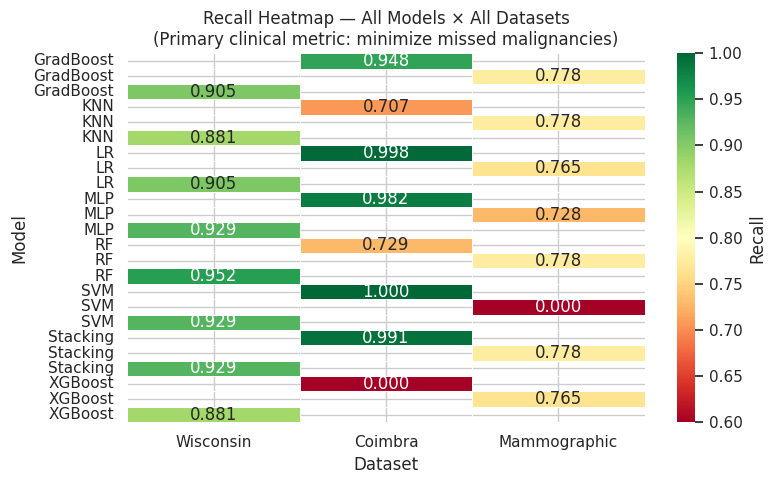

In [ ]:
# Heatmap: Recall across all models × all datasets (the key clinical metric)
recall_matrix = pd.DataFrame({
    "Wisconsin":    df_ds1["recall"],
    "Coimbra":      df_ds2["recall"],
    "Mammographic": df_ds3["recall"],
})
# Clean up index labels (strip dataset name)
recall_matrix.index = [n.split(" — ")[0] for n in recall_matrix.index]

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(recall_matrix, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0.6, vmax=1.0,
            linewidths=0.5, ax=ax, cbar_kws={"label": "Recall"})
ax.set_title("Recall Heatmap — All Models × All Datasets\n(Primary clinical metric: minimize missed malignancies)")
ax.set_xlabel("Dataset"); ax.set_ylabel("Model")
plt.tight_layout()
plt.show()

In [ ]:
# Results summary
print("=" * 65)
print("RESULTS SUMMARY")
print("=" * 65)
for label, df_res in [("Dataset 1 — Wisconsin (imaging)",   df_ds1),
                       ("Dataset 2 — Coimbra (biomarker)",   df_ds2),
                       ("Dataset 3 — Mammographic (clinical)", df_ds3)]:
  best_recall = df_res["recall"].idxmax()
  best_auc = df_res["auc"].idxmax()
  best_f1 = df_res["f1"].idxmax()
  print(f"\n{label}:")
  print(f"  Highest recall : {best_recall}  ({df_res.loc[best_recall, 'recall']:.4f})")
  print(f"  Highest ROC-AUC: {best_auc}  ({df_res.loc[best_auc, 'auc']:.4f})")
  print(f"  Highest F1     : {best_f1}  ({df_res.loc[best_f1, 'f1']:.4f})")



RESULTS SUMMARY

Dataset 1 — Wisconsin (imaging):
  Highest recall : RF — Wisconsin  (0.9524)
  Highest ROC-AUC: Stacking — Wisconsin  (0.9980)
  Highest F1     : Stacking — Wisconsin  (0.9630)

Dataset 2 — Coimbra (biomarker):
  Highest recall : SVM — Coimbra  (1.0000)
  Highest ROC-AUC: MLP — Coimbra  (0.5417)
  Highest F1     : SVM — Coimbra  (0.7128)

Dataset 3 — Mammographic (clinical):
  Highest recall : RF — Mammographic  (0.7778)
  Highest ROC-AUC: XGBoost — Mammographic  (0.8539)
  Highest F1     : GradBoost — Mammographic  (0.7778)


Note: Recall (sensitivity) is the primary metric. A false negative (missed malignancy) is clinically more harmful than a false positive (unnecessary follow-up), so we prioritize minimizing missed cases even at the cost of some precision.

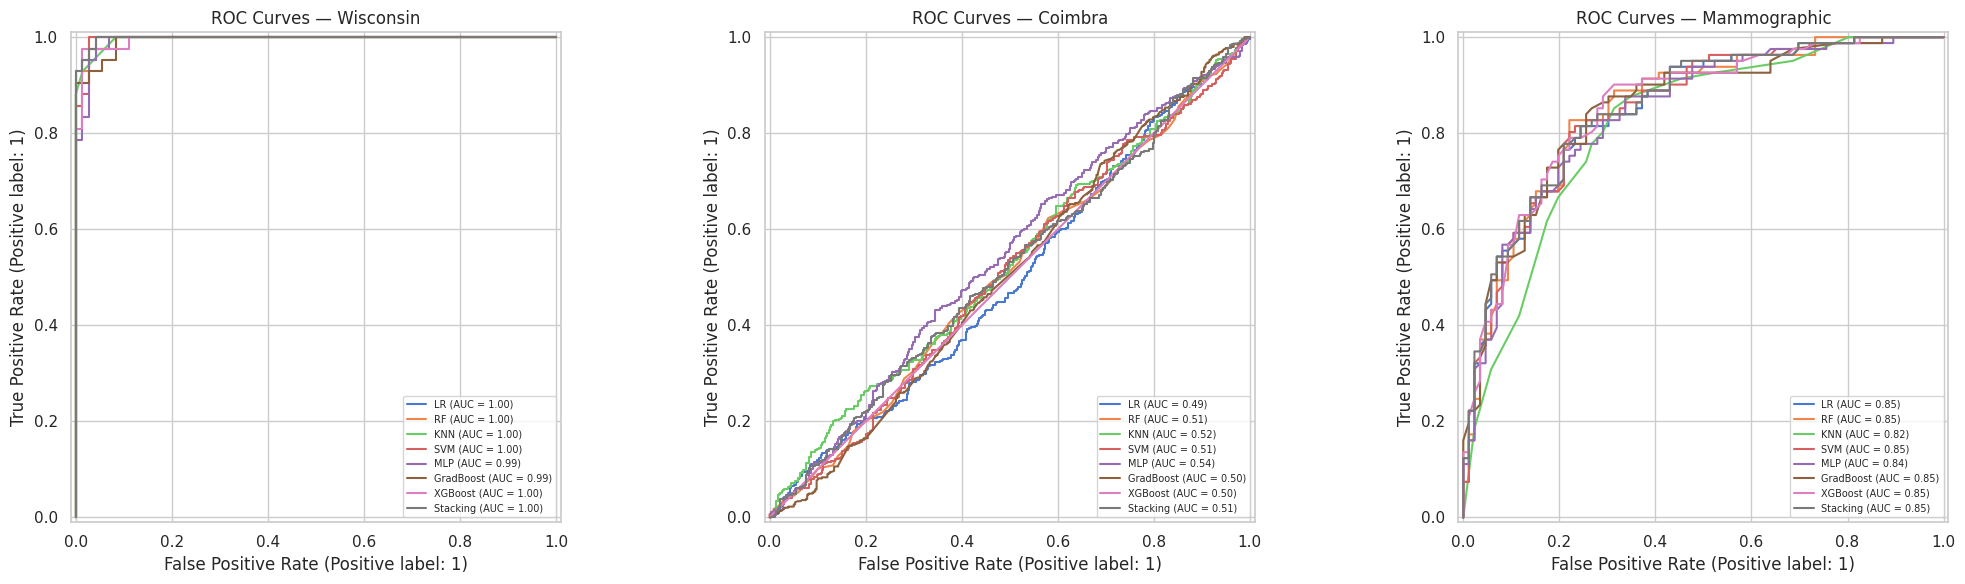

In [ ]:
# ROC curves — all models on both datasets
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

model_probs = [
    ("LR",       y1_prob_lr,    y2_prob_lr,    y3_prob_lr),
    ("RF",       y1_prob_rf,    y2_prob_rf,    y3_prob_rf),
    ("KNN",      y1_prob_knn,   y2_prob_knn,   y3_prob_knn),
    ("SVM",      y1_prob_svm,   y2_prob_svm,   y3_prob_svm),
    ("MLP",      y1_prob_mlp,   y2_prob_mlp,   y3_prob_mlp),
    ("GradBoost",y1_prob_gb,    y2_prob_gb,    y3_prob_gb),
    ("XGBoost",  y1_prob_xgb,   y2_prob_xgb,   y3_prob_xgb),
    ("Stacking", y1_prob_stack, y2_prob_stack, y3_prob_stack),
]

for name, p1, p2, p3 in model_probs:
  RocCurveDisplay.from_predictions(y1_te, p1, name=name, ax=axes[0])
  RocCurveDisplay.from_predictions(y2_te, p2, name=name, ax=axes[1])
  RocCurveDisplay.from_predictions(y3_te, p3, name=name, ax=axes[2])

axes[0].set_title("ROC Curves — Wisconsin")
axes[1].set_title("ROC Curves — Coimbra")
axes[2].set_title("ROC Curves — Mammographic")
for ax in axes: ax.legend(fontsize=7, loc="lower right")
plt.tight_layout()
plt.show()

In [ ]:
print("Dataset Characteristics Comparison")
print("-" * 55)
print(f"{'':25} {'Wisconsin':>10} {'Coimbra':>10} {'Mammographic':>12}")
print(f"{'Samples':25} {df1.shape[0]:>10} {df2.shape[0]:>10} {df3.shape[0]:>12}")
print(f"{'Features':25} {df1.shape[1]-2:>10} {df2.shape[1]-1:>10} {df3.shape[1]-1:>12}")
print(f"{'Feature type':25} {'Imaging':>10} {'Biomarker':>10} {'Clinical':>12}")
print(f"{'Class balance (maj %)':25} {357/569*100:>9.1f}% {int((df2['Classification']==2).sum())/len(df2)*100:>9.1f}% {int((df3['target']==0).sum())/len(df3)*100:>11.1f}%")

Dataset Characteristics Comparison
-------------------------------------------------------
                           Wisconsin    Coimbra Mammographic
Samples                          569       4000          831
Features                          30          9            4
Feature type                 Imaging  Biomarker     Clinical
Class balance (maj %)          62.7%      55.4%        51.5%


Note: The three datasets represent fundamentally different measurement modalities (cell nucleus geometry (FNA imaging, 30 features) vs. blood biomarkers (9 features) vs. clinical + radiologial features (5 features)). Performance differences across datasets reflect both dataset difficulty and feature informativeness, not model quality alone.

### Feature Importance Comparison Across Models

Different models attribute importance differently:
- **Logistic Regression**: magnitude of learned coefficients (linear contribution)
- **Random Forest**: mean impurity decrease across all trees (non-linear, interaction-aware)
- **Gradient Boosting**: same impurity-based measure but weighted by boosting stage

Comparing these across models tells us which features are robustly important (agreed upon by all models) vs. model-dependent.

Note: For Wisconsin, LR/KNN/SVM/MLP were trained on top_features1 (10 features), while  RF/GB/XGBoost were trained on all 30. We align to top_features1 here by slicing RF/GB/XGB importances to those same 10 features, then re-normalizing.

In [ ]:
# Feature importance comparison: LR vs RF vs GradBoost vs XGBoost on each dataset
def slice_importances(importances, all_feature_names, selected_features):
  """Extract and re-normalize importances for a subset of features."""
  idx = [list(all_feature_names).index(f) for f in selected_features]
  vals = importances[idx]
  return vals / vals.sum() if vals.sum() > 0 else vals

configs = [
    ("Wisconsin", top_features1, list(X1_all.columns),
     lr1,
     gs_rf1.best_estimator_,
     gs_gb1.best_estimator_,
     gs_xgb1.best_estimator_),
    ("Coimbra", list(X2_all.columns), list(X2_all.columns),
     lr2,
     gs_rf2.best_estimator_,
     gs_gb2.best_estimator_,
     gs_xgb2.best_estimator_),
    ("Mammographic", list(X3_all.columns), list(X3_all.columns),
     lr3,
     gs_rf3.best_estimator_,
     gs_gb3.best_estimator_,
     gs_xgb3.best_estimator_),
]

for ds_label, feat_names, all_feat_names, lr_model, rf_model, gb_model, xgb_model in configs:
  n = len(feat_names)
  lr_coef = np.abs(lr_model.coef_[0])
  lr_coef = lr_coef / lr_coef.sum()

  rf_imp = slice_importances(rf_model.feature_importances_, all_feat_names, feat_names)
  gb_imp = slice_importances(gb_model.feature_importances_, all_feat_names, feat_names)
  xgb_imp = slice_importances(xgb_model.feature_importances_, all_feat_names, feat_names)

  imp_df = pd.DataFrame({
      "LR |coef|":     lr_coef,
      "RF Importance": rf_imp,
      "GB Importance": gb_imp,
      "XGB Importance": xgb_imp,
  }, index=feat_names).sort_values("RF Importance", ascending=False)

  fig, ax = plt.subplots(figsize=(max(8, n * 0.9), 4))
  imp_df.plot(kind="bar", ax=ax)
  ax.set_title(f"Feature Importance Comparison — {ds_label}")
  ax.set_ylabel("Normalized Importance")
  ax.tick_params(axis="x", rotation=45)
  ax.legend(loc="upper right")
  plt.tight_layout()
  plt.show()

  rho_rf_gb,  p_rf_gb = spearmanr(imp_df["RF Importance"], imp_df["GB Importance"])
  rho_rf_xgb, p_rf_xgb = spearmanr(imp_df["RF Importance"], imp_df["XGB Importance"])
  rho_gb_xgb, p_gb_xgb = spearmanr(imp_df["GB Importance"], imp_df["XGB Importance"])
  print(f"{ds_label}:")
  print(f"  RF  vs GB  Spearman ρ = {rho_rf_gb:.3f}  (p={p_rf_gb:.4f})")
  print(f"  RF  vs XGB Spearman ρ = {rho_rf_xgb:.3f}  (p={p_rf_xgb:.4f})")
  print(f"  GB  vs XGB Spearman ρ = {rho_gb_xgb:.3f}  (p={p_gb_xgb:.4f})")
  print()

IndexError: index 27 is out of bounds for axis 0 with size 10

### Cross-Dataset Generalization Analysis

Wisconsin and Coimbra share a conceptual target (malignant vs. benign) but differ in measurement modality:
- **Wisconsin**: cell nucleus geometry from fine needle aspirate images (30 continuous features)
- **Coimbra**: blood biomarkers (9 features: Age, BMI, Glucose, Insulin, HOMA, Leptin, Adiponectin, Resistin, MCP-1)

We test whether a model trained on one dataset generalizes to the other by projecting both into a shared PCA space and examining separability. We also formally test cross-dataset transfer for a reduced feature set that is conceptually aligned (Glucose and BMI appear in Coimbra; we proxy these via the nearest Wisconsin analogues).

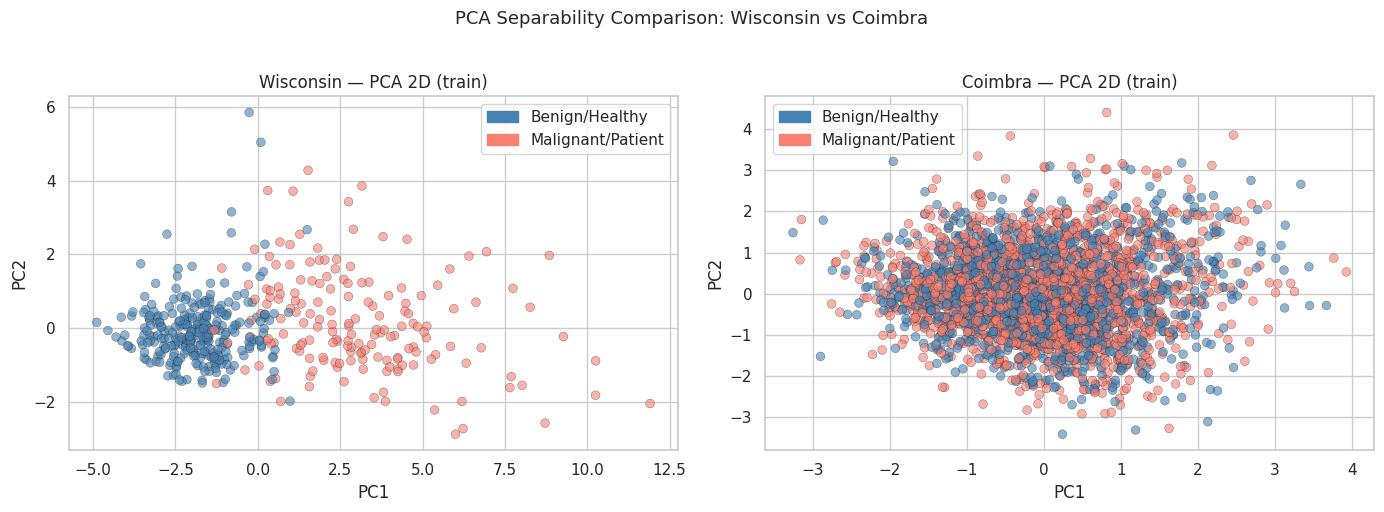

Class centroid separation in PCA space:
  Wisconsin : 4.8135
  Coimbra   : 0.0352


In [ ]:
# Cross-dataset generalization via PCA visualization

# Project each dataset to 2D PCA using its own scaler, then overlay
pca_w = PCA(n_components=2, random_state=RANDOM_STATE)
pca_c = PCA(n_components=2, random_state=RANDOM_STATE)

X1_pca = pca_w.fit_transform(X1_tr_s)
X2_pca = pca_c.fit_transform(X2_tr_s)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, X_pca, y, title in [
    (axes[0], X1_pca, y1_tr, "Wisconsin — PCA 2D (train)"),
    (axes[1], X2_pca, y2_tr, "Coimbra — PCA 2D (train)"),
]:
  colors = np.where(y == 1, "salmon", "steelblue")
  ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, alpha=0.6, edgecolors="k", linewidths=0.3, s=40)
  ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.set_title(title)
  benign_patch = mpatches.Patch(color="steelblue", label="Benign/Healthy")
  mal_patch = mpatches.Patch(color="salmon",    label="Malignant/Patient")
  ax.legend(handles=[benign_patch, mal_patch])

plt.suptitle("PCA Separability Comparison: Wisconsin vs Coimbra", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Cross-dataset transfer: train LR on Wisconsin top features,
# test concept transferability by comparing class centroid separability in each PCA space
from scipy.spatial.distance import cdist

# Centroid separation in PCA space
def centroid_separation(X, y):
  c0 = X[y == 0].mean(axis=0)
  c1 = X[y == 1].mean(axis=0)
  return np.linalg.norm(c1 - c0)

sep_w = centroid_separation(X1_pca, y1_tr.values)
sep_c = centroid_separation(X2_pca, y2_tr.values)

print("Class centroid separation in PCA space:")
print(f"  Wisconsin : {sep_w:.4f}")
print(f"  Coimbra   : {sep_c:.4f}")

Interpretation:

Wisconsin cell-geometry features produce well-separated clusters. Coimbra blood-biomarker features show weaker linear separation, consistent with its lower cross-model recall scores.

Cross-dataset direct transfer is not feasible: the feature spaces are entirely disjoint (cell geometry vs. systemic biomarkers). This reflects a fundamental domain gap, not a data quality issue.